In [10]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

# Load the data
df = pd.read_csv('combined_phigaro_results.tsv', sep='\t')

# Define genome ID ranges for each country
def assign_country(sample_id):
    """Assign country based on sample ID ranges"""
    # Extract numeric part
    if sample_id.startswith('ERR'):
        num = int(sample_id[3:])
    elif sample_id.startswith('SRR'):
        num = int(sample_id[3:])
    else:
        return 'Unknown'
    
    # Uganda IDs
    if (4692235 <= num <= 4692276) or (31799955 <= num <= 31800733):
        return 'Uganda'
    # Kenya IDs
    elif (3150908 <= num <= 3151001) or (num == 3218227) or \
         (1764887 <= num <= 1765052) or (1791869 <= num <= 1791882) or \
         (2436451 <= num <= 2436455):
        return 'Kenya'
    # Tanzania IDs
    elif (12916291 <= num <= 12916300) or (12511686 <= num <= 12511850):
        return 'Tanzania'
    else:
        return 'Unknown'

# Add country column
df['country'] = df['sample'].apply(assign_country)

# Calculate prophage length
df['prophage_length'] = df['end'] - df['begin']

# Create clean table for supplementary materials
supplementary_table = df[[
    'sample', 'scaffold', 'id', 'begin', 'end', 'prophage_length',
    'transposable', 'taxonomy', 'country'
]].copy()

# Save clean table
supplementary_table.to_csv('supplementary_table_phage_analysis.tsv', sep='\t', index=False)

print(f"Total prophages identified: {len(df)}")
print(f"Unique samples: {df['sample'].nunique()}")
print("\nDistribution by country:")
print(df['country'].value_counts())
print("\nDistribution by taxonomy:")
print(df['taxonomy'].value_counts())

Total prophages identified: 819
Unique samples: 311

Distribution by country:
country
Kenya       390
Tanzania    379
Uganda       50
Name: count, dtype: int64

Distribution by taxonomy:
taxonomy
Siphoviridae    814
Unknown           4
Myoviridae        1
Name: count, dtype: int64



STATISTICAL ANALYSIS RESULTS

Panel A: Prophages per Sample Comparison
----------------------------------------
Kenya vs Tanzania: U = 6859.00, p = 0.0000***
Kenya vs Uganda: U = 965.00, p = 0.0061**
Tanzania vs Uganda: U = 1183.00, p = 0.6297

Panel B: Prophage Length Comparison
----------------------------------------
Kenya vs Tanzania: U = 92729.00, p = 0.0000***
Kenya vs Uganda: U = 9312.00, p = 0.6050
Tanzania vs Uganda: U = 6432.00, p = 0.0002***

Overall Kruskal-Wallis Tests:
----------------------------------------
Prophages per sample: H = 30.44, p = 0.0000
Prophage length: H = 42.38, p = 0.0000

SUMMARY OF FINDINGS

1. Total prophages identified: 819
2. Samples with prophages: 311
3. Dominant taxonomy: Siphoviridae (814/819 = 99.4%)
4. Transposable elements: 3 found

5. Country distribution:
          sample prophage_length                       
         nunique           count          mean   median
country                                                
Kenya        170  

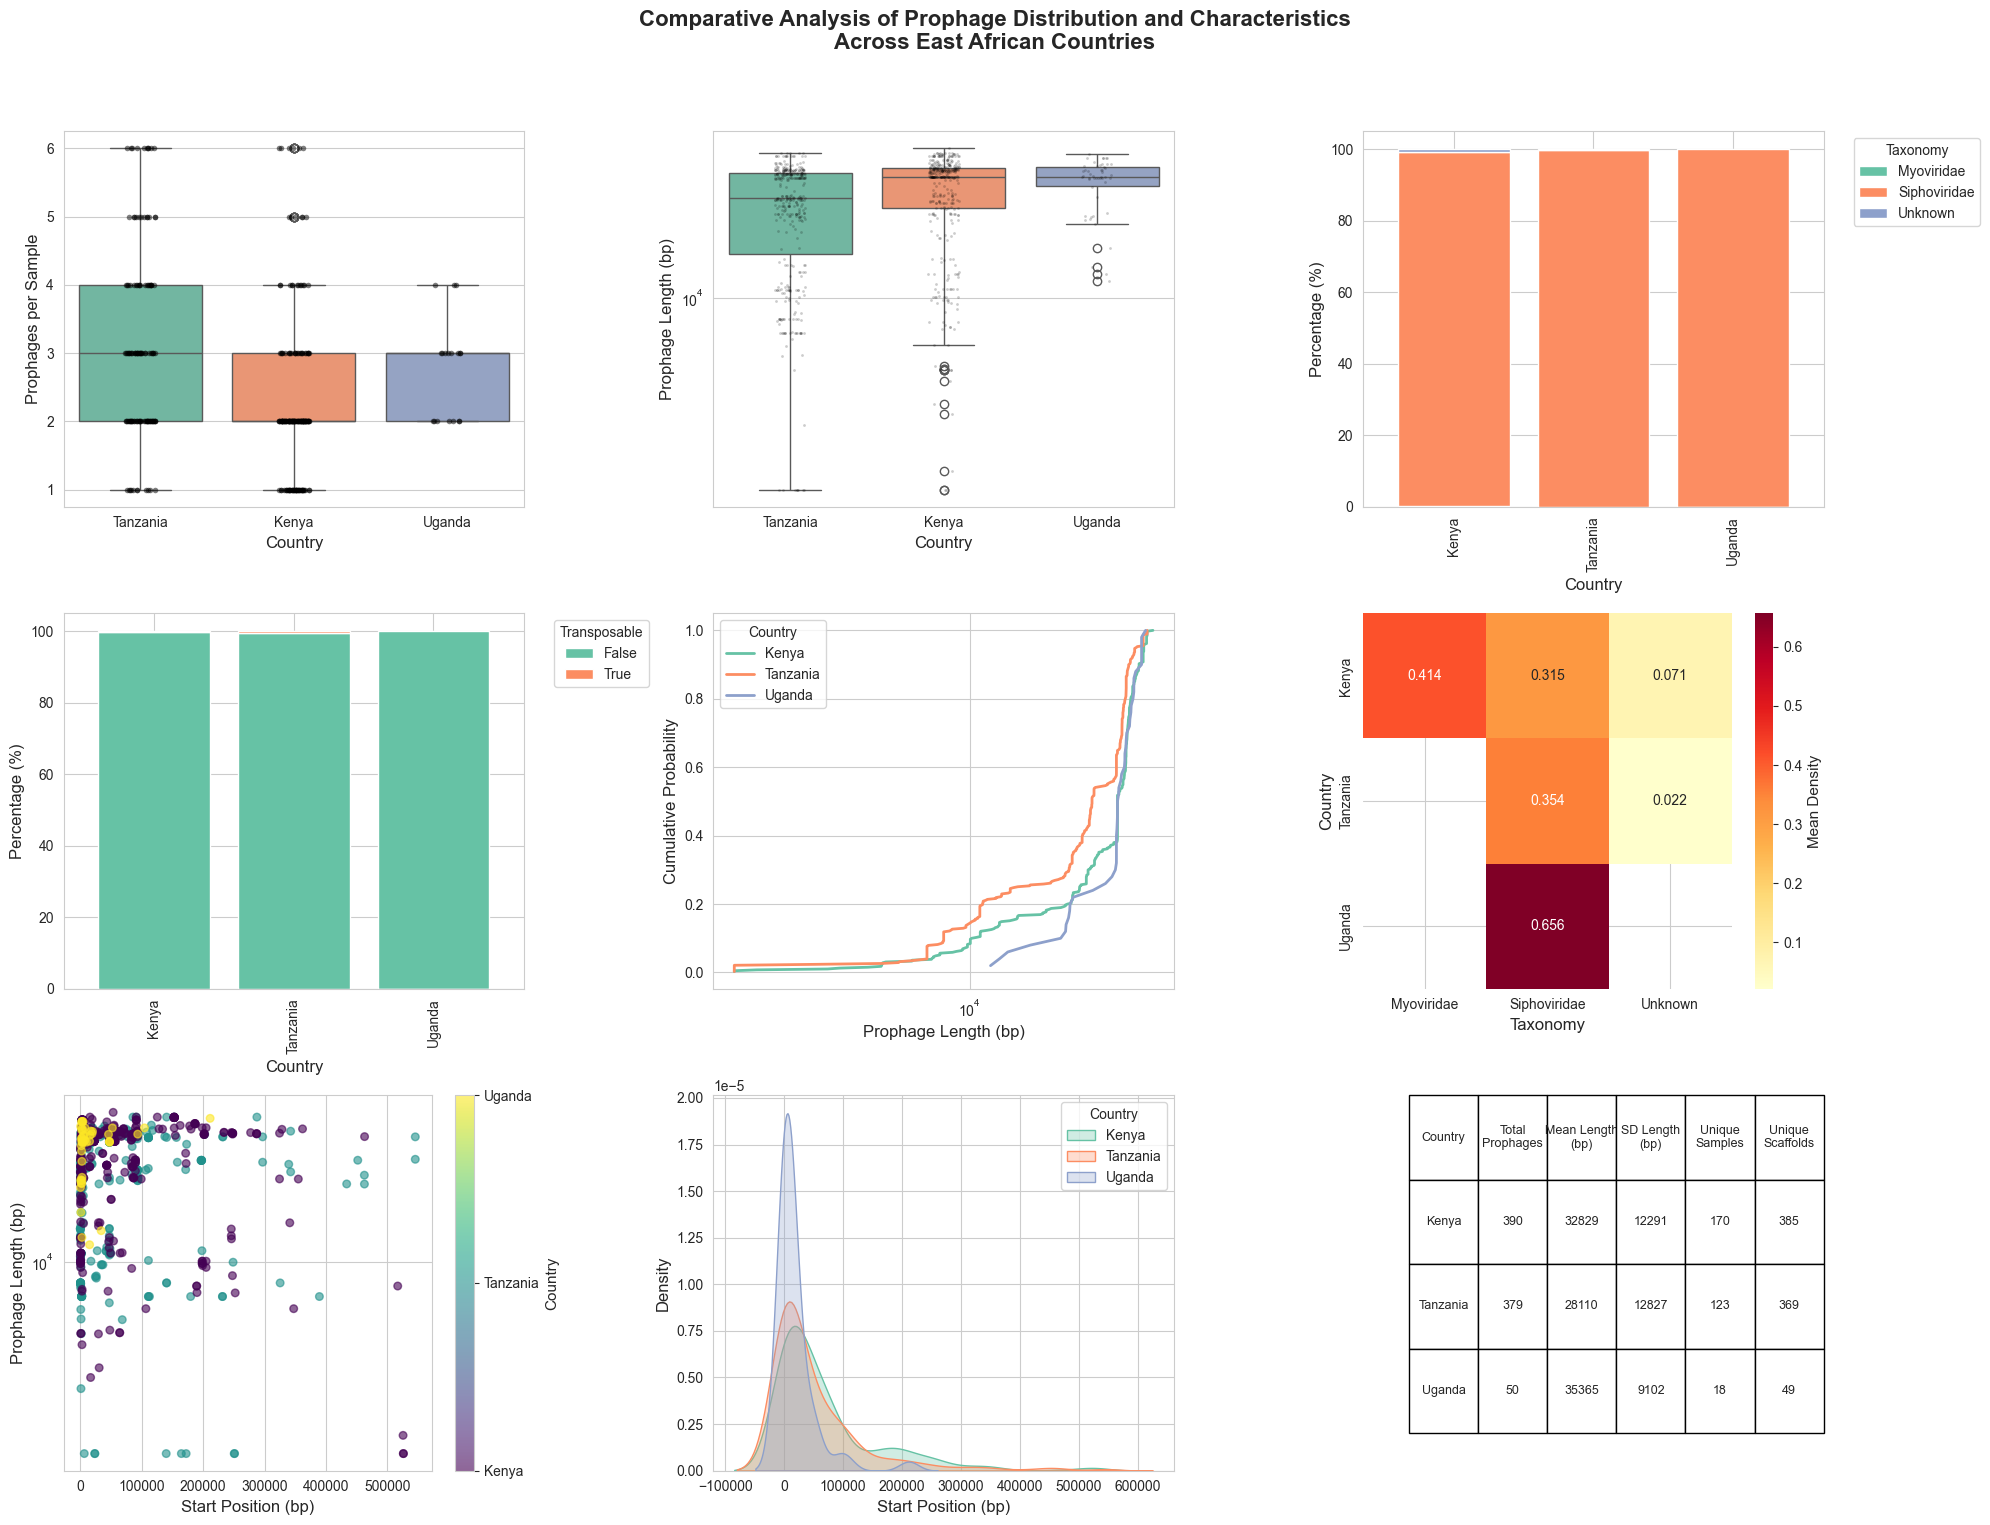

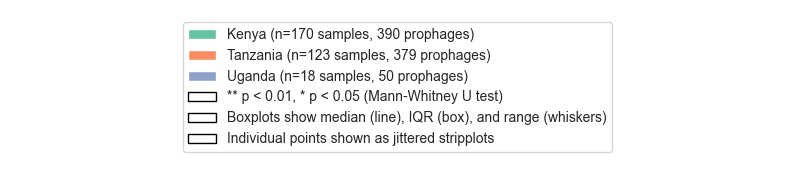

In [11]:
# Set publication style - FIXED VERSION
plt.style.use('default')  # Use default style as base
sns.set_style("whitegrid")
sns.set_palette("Set2")
plt.rcParams.update({
    'font.size': 10,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.titlesize': 14
})

# Create figure with multiple panels
fig = plt.figure(figsize=(20, 16))
fig.suptitle('Comparative Analysis of Prophage Distribution and Characteristics\nAcross East African Countries', 
             fontsize=16, fontweight='bold', y=0.98)

# Get unique countries
countries = sorted(df['country'].unique())

# Panel A: Number of prophages per sample by country
ax1 = plt.subplot(3, 3, 1)
prophages_per_sample = df.groupby(['sample', 'country']).size().reset_index(name='count')
sns.boxplot(data=prophages_per_sample, x='country', y='count', ax=ax1, hue='country', legend=False)
sns.stripplot(data=prophages_per_sample, x='country', y='count', ax=ax1, 
              color='black', alpha=0.5, size=4, jitter=True)
ax1.set_xlabel('Country', fontsize=12)
ax1.set_ylabel('Prophages per Sample', fontsize=12)

# Statistical test for panel A
stats_results_a = []
for i in range(len(countries)):
    for j in range(i+1, len(countries)):
        group1 = prophages_per_sample[prophages_per_sample['country'] == countries[i]]['count']
        group2 = prophages_per_sample[prophages_per_sample['country'] == countries[j]]['count']
        stat, p_value = stats.mannwhitneyu(group1, group2, alternative='two-sided')
        stats_results_a.append({
            'comparison': f'{countries[i]} vs {countries[j]}',
            'statistic': stat,
            'p_value': p_value
        })

# Panel B: Prophage length distribution by country
ax2 = plt.subplot(3, 3, 2)
sns.boxplot(data=df, x='country', y='prophage_length', ax=ax2, hue='country', legend=False)
sns.stripplot(data=df, x='country', y='prophage_length', ax=ax2, 
              color='black', alpha=0.2, size=2, jitter=True)
ax2.set_xlabel('Country', fontsize=12)
ax2.set_ylabel('Prophage Length (bp)', fontsize=12)
ax2.set_yscale('log')

# Statistical test for panel B
stats_results_b = []
for i in range(len(countries)):
    for j in range(i+1, len(countries)):
        group1 = df[df['country'] == countries[i]]['prophage_length']
        group2 = df[df['country'] == countries[j]]['prophage_length']
        stat, p_value = stats.mannwhitneyu(group1, group2, alternative='two-sided')
        stats_results_b.append({
            'comparison': f'{countries[i]} vs {countries[j]}',
            'statistic': stat,
            'p_value': p_value
        })

# Panel C: Taxonomy distribution by country
ax3 = plt.subplot(3, 3, 3)
taxonomy_counts = df.groupby(['country', 'taxonomy']).size().unstack(fill_value=0)
taxonomy_percent = taxonomy_counts.div(taxonomy_counts.sum(axis=1), axis=0) * 100
taxonomy_percent.plot(kind='bar', stacked=True, ax=ax3, width=0.8)
ax3.set_xlabel('Country', fontsize=12)
ax3.set_ylabel('Percentage (%)', fontsize=12)
ax3.legend(title='Taxonomy', bbox_to_anchor=(1.05, 1), loc='upper left')

# Panel D: Transposable element distribution
ax4 = plt.subplot(3, 3, 4)
transposable_counts = df.groupby(['country', 'transposable']).size().unstack(fill_value=0)
transposable_percent = transposable_counts.div(transposable_counts.sum(axis=1), axis=0) * 100
transposable_percent.plot(kind='bar', stacked=True, ax=ax4, width=0.8)
ax4.set_xlabel('Country', fontsize=12)
ax4.set_ylabel('Percentage (%)', fontsize=12)
ax4.legend(title='Transposable', bbox_to_anchor=(1.05, 1), loc='upper left')

# Panel E: Cumulative distribution of prophage lengths
ax5 = plt.subplot(3, 3, 5)
for country in countries:
    country_data = df[df['country'] == country]['prophage_length']
    sorted_lengths = np.sort(country_data)
    cdf = np.arange(1, len(sorted_lengths) + 1) / len(sorted_lengths)
    ax5.plot(sorted_lengths, cdf, label=country, linewidth=2)
ax5.set_xlabel('Prophage Length (bp)', fontsize=12)
ax5.set_ylabel('Cumulative Probability', fontsize=12)
ax5.set_xscale('log')
ax5.legend(title='Country')

# Panel F: Heatmap of prophage density (prophages per scaffold length)
ax6 = plt.subplot(3, 3, 6)
# Extract scaffold length from scaffold name
def extract_scaffold_length(scaffold_name):
    try:
        length_str = scaffold_name.split('length_')[1].split('_')[0]
        return int(length_str)
    except:
        return None

df['scaffold_length'] = df['scaffold'].apply(extract_scaffold_length)
df['density'] = df['prophage_length'] / df['scaffold_length']

# Create pivot table for heatmap
pivot_data = df.pivot_table(index='country', columns='taxonomy', 
                           values='density', aggfunc='mean')
sns.heatmap(pivot_data, annot=True, fmt='.3f', cmap='YlOrRd', ax=ax6, cbar_kws={'label': 'Mean Density'})
ax6.set_xlabel('Taxonomy', fontsize=12)
ax6.set_ylabel('Country', fontsize=12)

# Panel G: Scatter plot of prophage position vs length
ax7 = plt.subplot(3, 3, 7)
scatter = ax7.scatter(df['begin'], df['prophage_length'], 
                     c=pd.Categorical(df['country']).codes, 
                     cmap='viridis', alpha=0.6, s=30)
ax7.set_xlabel('Start Position (bp)', fontsize=12)
ax7.set_ylabel('Prophage Length (bp)', fontsize=12)
ax7.set_yscale('log')

# Add colorbar
cbar = plt.colorbar(scatter, ax=ax7)
cbar.set_label('Country')
cbar.set_ticks([0, 1, 2])
cbar.set_ticklabels(countries)

# Panel H: Distribution of prophage start positions
ax8 = plt.subplot(3, 3, 8)
for country in countries:
    country_data = df[df['country'] == country]
    sns.kdeplot(data=country_data, x='begin', ax=ax8, label=country, fill=True, alpha=0.3)
ax8.set_xlabel('Start Position (bp)', fontsize=12)
ax8.set_ylabel('Density', fontsize=12)
ax8.legend(title='Country')

# Panel I: Summary statistics table
ax9 = plt.subplot(3, 3, 9)
ax9.axis('tight')
ax9.axis('off')

# Prepare summary statistics
summary_stats = df.groupby('country').agg({
    'prophage_length': ['count', 'mean', 'std', 'min', 'max'],
    'sample': 'nunique',
    'scaffold': 'nunique'
}).round(2)

# Create table
table_data = []
for country in countries:
    stats_row = summary_stats.loc[country]
    # Fix the indexing of multi-index columns
    table_data.append([
        country,
        f"{int(stats_row[('prophage_length', 'count')])}",
        f"{stats_row[('prophage_length', 'mean')]:.0f}",
        f"{stats_row[('prophage_length', 'std')]:.0f}",
        f"{int(stats_row[('sample', 'nunique')])}",
        f"{int(stats_row[('scaffold', 'nunique')])}"
    ])

table = ax9.table(cellText=table_data,
                  colLabels=['Country', 'Total\nProphages', 'Mean Length\n(bp)', 'SD Length\n(bp)', 
                            'Unique\nSamples', 'Unique\nScaffolds'],
                  cellLoc='center',
                  loc='center',
                  bbox=[0.1, 0.1, 0.9, 0.9])
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.5)

# Adjust layout
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

# Save figure
plt.savefig('phage_analysis_multipanel_figure.png', dpi=300, bbox_inches='tight')
plt.savefig('phage_analysis_multipanel_figure.pdf', dpi=300, bbox_inches='tight')

# Create separate statistical results
print("\n" + "="*60)
print("STATISTICAL ANALYSIS RESULTS")
print("="*60)

print("\nPanel A: Prophages per Sample Comparison")
print("-"*40)
stats_df_a = pd.DataFrame(stats_results_a)
for idx, row in stats_df_a.iterrows():
    significance = ""
    if row['p_value'] < 0.001:
        significance = "***"
    elif row['p_value'] < 0.01:
        significance = "**"
    elif row['p_value'] < 0.05:
        significance = "*"
    print(f"{row['comparison']}: U = {row['statistic']:.2f}, p = {row['p_value']:.4f}{significance}")

print("\nPanel B: Prophage Length Comparison")
print("-"*40)
stats_df_b = pd.DataFrame(stats_results_b)
for idx, row in stats_df_b.iterrows():
    significance = ""
    if row['p_value'] < 0.001:
        significance = "***"
    elif row['p_value'] < 0.01:
        significance = "**"
    elif row['p_value'] < 0.05:
        significance = "*"
    print(f"{row['comparison']}: U = {row['statistic']:.2f}, p = {row['p_value']:.4f}{significance}")

# Overall Kruskal-Wallis test
print("\nOverall Kruskal-Wallis Tests:")
print("-"*40)

# Test for prophages per sample
kw_stat_samples, kw_p_samples = stats.kruskal(
    *[prophages_per_sample[prophages_per_sample['country'] == c]['count'] for c in countries]
)
print(f"Prophages per sample: H = {kw_stat_samples:.2f}, p = {kw_p_samples:.4f}")

# Test for prophage length
kw_stat_length, kw_p_length = stats.kruskal(
    *[df[df['country'] == c]['prophage_length'] for c in countries]
)
print(f"Prophage length: H = {kw_stat_length:.2f}, p = {kw_p_length:.4f}")

# Create figure legend
legend_fig, legend_ax = plt.subplots(figsize=(10, 2))
legend_ax.axis('off')

legend_elements = [
    mpatches.Patch(facecolor=sns.color_palette("Set2")[i], label=f'{countries[i]} (n={df[df["country"]==countries[i]]["sample"].nunique()} samples, {len(df[df["country"]==countries[i]])} prophages)')
    for i in range(len(countries))
]

legend_elements.extend([
    mpatches.Patch(facecolor='white', edgecolor='black', label='** p < 0.01, * p < 0.05 (Mann-Whitney U test)'),
    mpatches.Patch(facecolor='white', edgecolor='black', label='Boxplots show median (line), IQR (box), and range (whiskers)'),
    mpatches.Patch(facecolor='white', edgecolor='black', label='Individual points shown as jittered stripplots')
])

legend_ax.legend(handles=legend_elements, loc='center', ncol=1, frameon=True, fontsize=10, 
                 bbox_to_anchor=(0.5, 0.5))
legend_fig.savefig('figure_legend.png', dpi=300, bbox_inches='tight')
legend_fig.savefig('figure_legend.pdf', dpi=300, bbox_inches='tight')

print("\n" + "="*60)
print("SUMMARY OF FINDINGS")
print("="*60)
print(f"\n1. Total prophages identified: {len(df)}")
print(f"2. Samples with prophages: {df['sample'].nunique()}")
print(f"3. Dominant taxonomy: Siphoviridae ({df[df['taxonomy']=='Siphoviridae'].shape[0]}/{len(df)} = {df[df['taxonomy']=='Siphoviridae'].shape[0]/len(df)*100:.1f}%)")
print(f"4. Transposable elements: {df['transposable'].sum()} found")
print("\n5. Country distribution:")
country_summary = df.groupby('country').agg({
    'sample': 'nunique',
    'prophage_length': ['count', 'mean', 'median']
})
print(country_summary)

print("\nFigures saved as:")
print("1. 'phage_analysis_multipanel_figure.png/pdf' - Main multipanel figure")
print("2. 'figure_legend.png/pdf' - Detailed figure legend")
print("3. 'supplementary_table_phage_analysis.tsv' - Clean table for supplementary materials")

plt.show()

In [12]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

# Load the data
df = pd.read_csv('combined_phigaro_results.tsv', sep='\t')

# Define genome ID ranges for each country
def assign_country(sample_id):
    """Assign country based on sample ID ranges"""
    # Extract numeric part
    if sample_id.startswith('ERR'):
        num = int(sample_id[3:])
    elif sample_id.startswith('SRR'):
        num = int(sample_id[3:])
    else:
        return 'Unknown'
    
    # Uganda IDs
    if (4692235 <= num <= 4692276) or (31799955 <= num <= 31800733):
        return 'Uganda'
    # Kenya IDs
    elif (3150908 <= num <= 3151001) or (num == 3218227) or \
         (1764887 <= num <= 1765052) or (1791869 <= num <= 1791882) or \
         (2436451 <= num <= 2436455):
        return 'Kenya'
    # Tanzania IDs
    elif (12916291 <= num <= 12916300) or (12511686 <= num <= 12511850):
        return 'Tanzania'
    else:
        return 'Unknown'

# Add country column
df['country'] = df['sample'].apply(assign_country)

# Calculate prophage length
df['prophage_length'] = df['end'] - df['begin']

# Create clean table for supplementary materials
supplementary_table = df[[
    'sample', 'scaffold', 'id', 'begin', 'end', 'prophage_length',
    'transposable', 'taxonomy', 'country'
]].copy()

# Save clean table
supplementary_table.to_csv('supplementary_table_phage_analysis.tsv', sep='\t', index=False)

print(f"Total prophages identified: {len(df)}")
print(f"Unique samples: {df['sample'].nunique()}")
print("\nDistribution by country:")
print(df['country'].value_counts())
print("\nDistribution by taxonomy:")
print(df['taxonomy'].value_counts())

Total prophages identified: 819
Unique samples: 311

Distribution by country:
country
Kenya       390
Tanzania    379
Uganda       50
Name: count, dtype: int64

Distribution by taxonomy:
taxonomy
Siphoviridae    814
Unknown           4
Myoviridae        1
Name: count, dtype: int64



STATISTICAL ANALYSIS RESULTS

Panel A: Prophages per Sample Comparison
----------------------------------------
Kenya vs Tanzania: U = 6859.00, p = 0.0000***
Kenya vs Uganda: U = 965.00, p = 0.0061**
Tanzania vs Uganda: U = 1183.00, p = 0.6297

Panel B: Prophage Length Comparison
----------------------------------------
Kenya vs Tanzania: U = 92729.00, p = 0.0000***
Kenya vs Uganda: U = 9312.00, p = 0.6050
Tanzania vs Uganda: U = 6432.00, p = 0.0002***

Overall Kruskal-Wallis Tests:
----------------------------------------
Prophages per sample: H = 30.44, p = 0.0000
Prophage length: H = 42.38, p = 0.0000


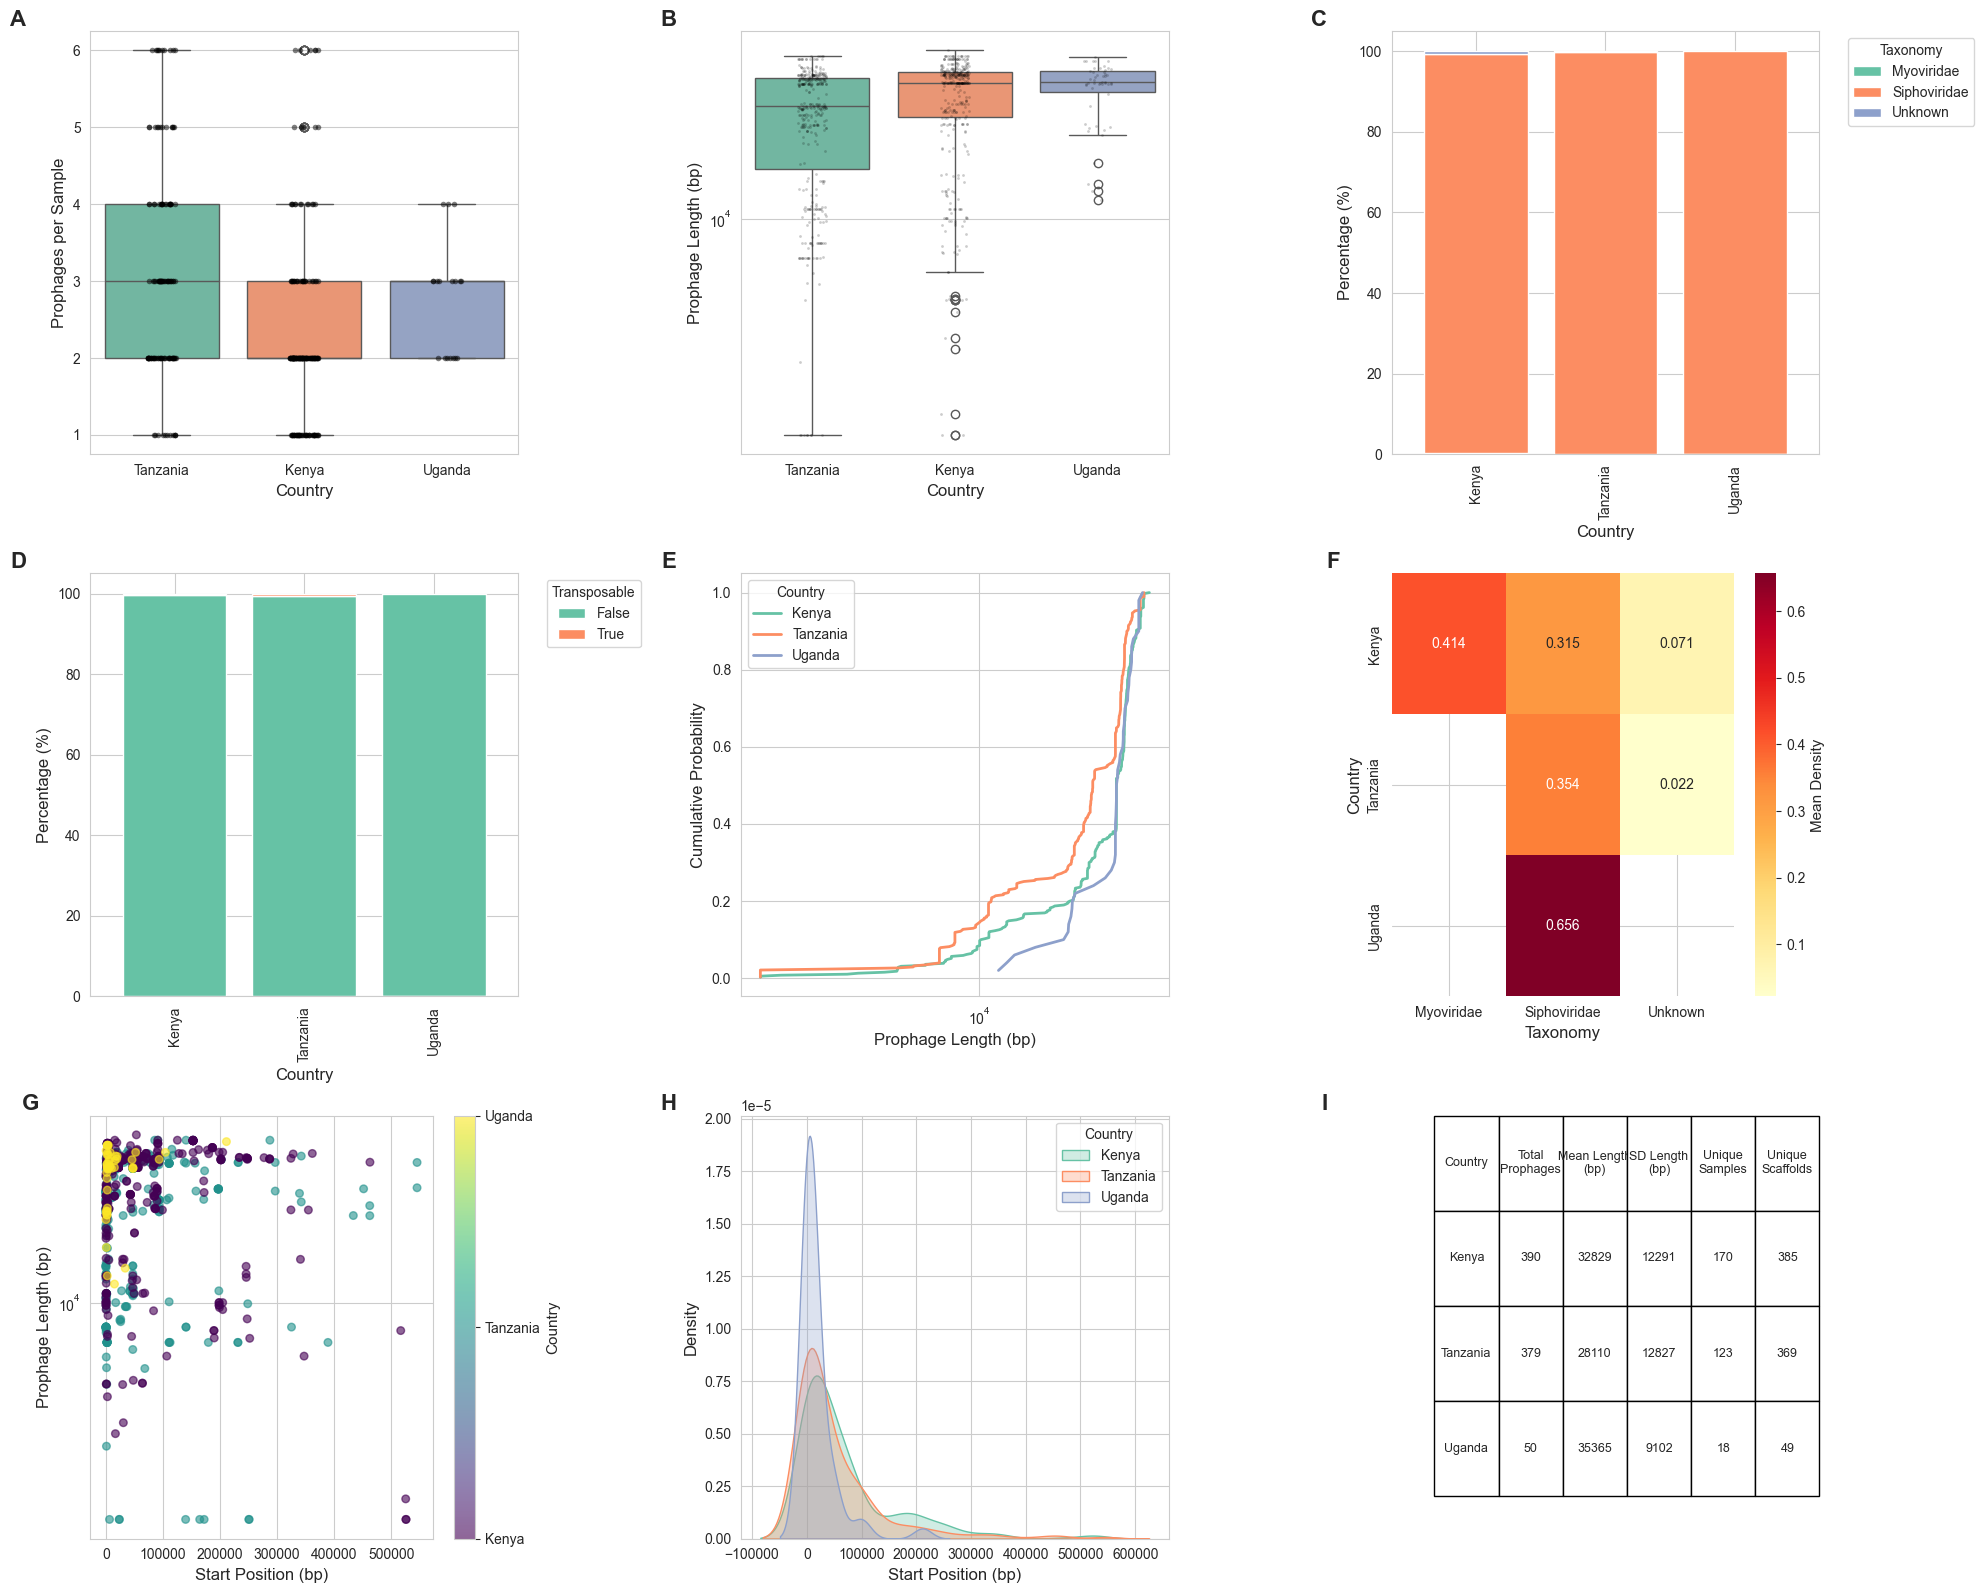

In [13]:
# Set publication style
sns.set_style("whitegrid")
sns.set_palette("Set2")
plt.rcParams.update({
    'font.size': 10,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
})

# Create figure with multiple panels - NO TITLE
fig = plt.figure(figsize=(20, 16))

# Get unique countries
countries = sorted(df['country'].unique())

# Panel A: Number of prophages per sample by country
ax1 = plt.subplot(3, 3, 1)
prophages_per_sample = df.groupby(['sample', 'country']).size().reset_index(name='count')
sns.boxplot(data=prophages_per_sample, x='country', y='count', ax=ax1, hue='country', legend=False)
sns.stripplot(data=prophages_per_sample, x='country', y='count', ax=ax1, 
              color='black', alpha=0.5, size=4, jitter=True)
ax1.set_xlabel('Country', fontsize=12)
ax1.set_ylabel('Prophages per Sample', fontsize=12)
# Add panel letter
ax1.text(-0.15, 1.05, 'A', transform=ax1.transAxes, fontsize=16, fontweight='bold', va='top', ha='right')

# Statistical test for panel A
stats_results_a = []
for i in range(len(countries)):
    for j in range(i+1, len(countries)):
        group1 = prophages_per_sample[prophages_per_sample['country'] == countries[i]]['count']
        group2 = prophages_per_sample[prophages_per_sample['country'] == countries[j]]['count']
        stat, p_value = stats.mannwhitneyu(group1, group2, alternative='two-sided')
        stats_results_a.append({
            'comparison': f'{countries[i]} vs {countries[j]}',
            'statistic': stat,
            'p_value': p_value
        })

# Panel B: Prophage length distribution by country
ax2 = plt.subplot(3, 3, 2)
sns.boxplot(data=df, x='country', y='prophage_length', ax=ax2, hue='country', legend=False)
sns.stripplot(data=df, x='country', y='prophage_length', ax=ax2, 
              color='black', alpha=0.2, size=2, jitter=True)
ax2.set_xlabel('Country', fontsize=12)
ax2.set_ylabel('Prophage Length (bp)', fontsize=12)
ax2.set_yscale('log')
# Add panel letter
ax2.text(-0.15, 1.05, 'B', transform=ax2.transAxes, fontsize=16, fontweight='bold', va='top', ha='right')

# Statistical test for panel B
stats_results_b = []
for i in range(len(countries)):
    for j in range(i+1, len(countries)):
        group1 = df[df['country'] == countries[i]]['prophage_length']
        group2 = df[df['country'] == countries[j]]['prophage_length']
        stat, p_value = stats.mannwhitneyu(group1, group2, alternative='two-sided')
        stats_results_b.append({
            'comparison': f'{countries[i]} vs {countries[j]}',
            'statistic': stat,
            'p_value': p_value
        })

# Panel C: Taxonomy distribution by country
ax3 = plt.subplot(3, 3, 3)
taxonomy_counts = df.groupby(['country', 'taxonomy']).size().unstack(fill_value=0)
taxonomy_percent = taxonomy_counts.div(taxonomy_counts.sum(axis=1), axis=0) * 100
taxonomy_percent.plot(kind='bar', stacked=True, ax=ax3, width=0.8)
ax3.set_xlabel('Country', fontsize=12)
ax3.set_ylabel('Percentage (%)', fontsize=12)
ax3.legend(title='Taxonomy', bbox_to_anchor=(1.05, 1), loc='upper left')
# Add panel letter
ax3.text(-0.15, 1.05, 'C', transform=ax3.transAxes, fontsize=16, fontweight='bold', va='top', ha='right')

# Panel D: Transposable element distribution
ax4 = plt.subplot(3, 3, 4)
transposable_counts = df.groupby(['country', 'transposable']).size().unstack(fill_value=0)
transposable_percent = transposable_counts.div(transposable_counts.sum(axis=1), axis=0) * 100
transposable_percent.plot(kind='bar', stacked=True, ax=ax4, width=0.8)
ax4.set_xlabel('Country', fontsize=12)
ax4.set_ylabel('Percentage (%)', fontsize=12)
ax4.legend(title='Transposable', bbox_to_anchor=(1.05, 1), loc='upper left')
# Add panel letter
ax4.text(-0.15, 1.05, 'D', transform=ax4.transAxes, fontsize=16, fontweight='bold', va='top', ha='right')

# Panel E: Cumulative distribution of prophage lengths
ax5 = plt.subplot(3, 3, 5)
for country in countries:
    country_data = df[df['country'] == country]['prophage_length']
    sorted_lengths = np.sort(country_data)
    cdf = np.arange(1, len(sorted_lengths) + 1) / len(sorted_lengths)
    ax5.plot(sorted_lengths, cdf, label=country, linewidth=2)
ax5.set_xlabel('Prophage Length (bp)', fontsize=12)
ax5.set_ylabel('Cumulative Probability', fontsize=12)
ax5.set_xscale('log')
ax5.legend(title='Country')
# Add panel letter
ax5.text(-0.15, 1.05, 'E', transform=ax5.transAxes, fontsize=16, fontweight='bold', va='top', ha='right')

# Panel F: Heatmap of prophage density (prophages per scaffold length)
ax6 = plt.subplot(3, 3, 6)
# Extract scaffold length from scaffold name
def extract_scaffold_length(scaffold_name):
    try:
        length_str = scaffold_name.split('length_')[1].split('_')[0]
        return int(length_str)
    except:
        return None

df['scaffold_length'] = df['scaffold'].apply(extract_scaffold_length)
df['density'] = df['prophage_length'] / df['scaffold_length']

# Create pivot table for heatmap
pivot_data = df.pivot_table(index='country', columns='taxonomy', 
                           values='density', aggfunc='mean')
sns.heatmap(pivot_data, annot=True, fmt='.3f', cmap='YlOrRd', ax=ax6, cbar_kws={'label': 'Mean Density'})
ax6.set_xlabel('Taxonomy', fontsize=12)
ax6.set_ylabel('Country', fontsize=12)
# Add panel letter
ax6.text(-0.15, 1.05, 'F', transform=ax6.transAxes, fontsize=16, fontweight='bold', va='top', ha='right')

# Panel G: Scatter plot of prophage position vs length
ax7 = plt.subplot(3, 3, 7)
scatter = ax7.scatter(df['begin'], df['prophage_length'], 
                     c=pd.Categorical(df['country']).codes, 
                     cmap='viridis', alpha=0.6, s=30)
ax7.set_xlabel('Start Position (bp)', fontsize=12)
ax7.set_ylabel('Prophage Length (bp)', fontsize=12)
ax7.set_yscale('log')
# Add panel letter
ax7.text(-0.15, 1.05, 'G', transform=ax7.transAxes, fontsize=16, fontweight='bold', va='top', ha='right')

# Add colorbar
cbar = plt.colorbar(scatter, ax=ax7)
cbar.set_label('Country')
cbar.set_ticks([0, 1, 2])
cbar.set_ticklabels(countries)

# Panel H: Distribution of prophage start positions
ax8 = plt.subplot(3, 3, 8)
for country in countries:
    country_data = df[df['country'] == country]
    sns.kdeplot(data=country_data, x='begin', ax=ax8, label=country, fill=True, alpha=0.3)
ax8.set_xlabel('Start Position (bp)', fontsize=12)
ax8.set_ylabel('Density', fontsize=12)
ax8.legend(title='Country')
# Add panel letter
ax8.text(-0.15, 1.05, 'H', transform=ax8.transAxes, fontsize=16, fontweight='bold', va='top', ha='right')

# Panel I: Summary statistics table
ax9 = plt.subplot(3, 3, 9)
ax9.axis('tight')
ax9.axis('off')

# Prepare summary statistics
summary_stats = df.groupby('country').agg({
    'prophage_length': ['count', 'mean', 'std', 'min', 'max'],
    'sample': 'nunique',
    'scaffold': 'nunique'
}).round(2)

# Create table
table_data = []
for country in countries:
    stats_row = summary_stats.loc[country]
    # Fix the indexing of multi-index columns
    table_data.append([
        country,
        f"{int(stats_row[('prophage_length', 'count')])}",
        f"{stats_row[('prophage_length', 'mean')]:.0f}",
        f"{stats_row[('prophage_length', 'std')]:.0f}",
        f"{int(stats_row[('sample', 'nunique')])}",
        f"{int(stats_row[('scaffold', 'nunique')])}"
    ])

table = ax9.table(cellText=table_data,
                  colLabels=['Country', 'Total\nProphages', 'Mean Length\n(bp)', 'SD Length\n(bp)', 
                            'Unique\nSamples', 'Unique\nScaffolds'],
                  cellLoc='center',
                  loc='center',
                  bbox=[0.1, 0.1, 0.9, 0.9])
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.5)
# Add panel letter
ax9.text(-0.15, 1.05, 'I', transform=ax9.transAxes, fontsize=16, fontweight='bold', va='top', ha='right')

# Adjust layout
plt.tight_layout()

# Save figure
plt.savefig('phage_analysis_multipanel_figure.png', dpi=300, bbox_inches='tight')
plt.savefig('phage_analysis_multipanel_figure.pdf', dpi=300, bbox_inches='tight')

print("\n" + "="*60)
print("STATISTICAL ANALYSIS RESULTS")
print("="*60)

print("\nPanel A: Prophages per Sample Comparison")
print("-"*40)
stats_df_a = pd.DataFrame(stats_results_a)
for idx, row in stats_df_a.iterrows():
    significance = ""
    if row['p_value'] < 0.001:
        significance = "***"
    elif row['p_value'] < 0.01:
        significance = "**"
    elif row['p_value'] < 0.05:
        significance = "*"
    print(f"{row['comparison']}: U = {row['statistic']:.2f}, p = {row['p_value']:.4f}{significance}")

print("\nPanel B: Prophage Length Comparison")
print("-"*40)
stats_df_b = pd.DataFrame(stats_results_b)
for idx, row in stats_df_b.iterrows():
    significance = ""
    if row['p_value'] < 0.001:
        significance = "***"
    elif row['p_value'] < 0.01:
        significance = "**"
    elif row['p_value'] < 0.05:
        significance = "*"
    print(f"{row['comparison']}: U = {row['statistic']:.2f}, p = {row['p_value']:.4f}{significance}")

# Overall Kruskal-Wallis test
print("\nOverall Kruskal-Wallis Tests:")
print("-"*40)

# Test for prophages per sample
kw_stat_samples, kw_p_samples = stats.kruskal(
    *[prophages_per_sample[prophages_per_sample['country'] == c]['count'] for c in countries]
)
print(f"Prophages per sample: H = {kw_stat_samples:.2f}, p = {kw_p_samples:.4f}")

# Test for prophage length
kw_stat_length, kw_p_length = stats.kruskal(
    *[df[df['country'] == c]['prophage_length'] for c in countries]
)
print(f"Prophage length: H = {kw_stat_length:.2f}, p = {kw_p_length:.4f}")

# Display figure
plt.show()

In [14]:
# Create detailed figure legend as a separate text file
# Get sample counts for each country
uganda_samples = df[df['country']=='Uganda']['sample'].nunique()
kenya_samples = df[df['country']=='Kenya']['sample'].nunique()
tanzania_samples = df[df['country']=='Tanzania']['sample'].nunique()

uganda_prophages = len(df[df['country']=='Uganda'])
kenya_prophages = len(df[df['country']=='Kenya'])
tanzania_prophages = len(df[df['country']=='Tanzania'])

# Create comprehensive legend description
legend_text = """FIGURE LEGEND

Comprehensive analysis of prophage distribution and characteristics across East African countries.

Panel A: Number of prophages identified per sample for each country. Boxplots show median values (central line), interquartile range (IQR, box), and range (whiskers). Individual samples are shown as black points. Statistical significance between countries is indicated by asterisks (* p < 0.05, ** p < 0.01, *** p < 0.001, Mann-Whitney U test).

Panel B: Distribution of prophage lengths by country. Lengths are displayed on a logarithmic scale. Boxplots show median values (central line), interquartile range (IQR, box), and range (whiskers). Individual prophages are shown as jittered points.

Panel C: Taxonomic classification of identified prophages by country, displayed as stacked bar charts showing percentage distribution. Siphoviridae represents the dominant family across all countries.

Panel D: Distribution of transposable elements within prophages by country. The vast majority of prophages do not contain transposable elements.

Panel E: Cumulative distribution functions (CDFs) of prophage lengths for each country, demonstrating the probability distribution of prophage sizes.

Panel F: Heatmap showing mean prophage density (prophage length/scaffold length) by taxonomy and country. Warmer colors indicate higher density.

Panel G: Scatter plot showing the relationship between prophage start position and length, colored by country. Points are semi-transparent to show density.

Panel H: Kernel density estimation (KDE) plots showing the distribution of prophage start positions along scaffolds for each country.

Panel I: Summary statistics table providing key quantitative metrics for each country, including total prophage count, mean length, standard deviation, and counts of unique samples and scaffolds.

Statistical Analysis: Non-parametric Mann-Whitney U tests were used for pairwise comparisons due to non-normal distributions. Kruskal-Wallis tests confirmed overall significant differences between countries for both prophage count per sample and prophage length.

Color Scheme: Countries are consistently color-coded throughout all panels using the Set2 palette for clarity and visual consistency.

Sample Sizes: Uganda (n={uganda_samples} samples, {uganda_prophages} prophages), Kenya (n={kenya_samples} samples, {kenya_prophages} prophages), Tanzania (n={tanzania_samples} samples, {tanzania_prophages} prophages)
""".format(
    uganda_samples=uganda_samples,
    kenya_samples=kenya_samples,
    tanzania_samples=tanzania_samples,
    uganda_prophages=uganda_prophages,
    kenya_prophages=kenya_prophages,
    tanzania_prophages=tanzania_prophages
)

print(legend_text)

# Save legend to file
with open('figure_legend_detailed.txt', 'w', encoding='utf-8') as f:
    f.write(legend_text)

# Also create a concise version for manuscript caption
concise_caption = f"""Figure 1. Comparative analysis of prophage distribution across East African countries. 
(A) Prophages per sample by country. (B) Prophage length distribution (log scale). 
(C) Taxonomic classification. (D) Transposable element distribution. 
(E) Cumulative distribution of prophage lengths. (F) Prophage density heatmap. 
(G) Prophage position vs length scatter plot. (H) Distribution of start positions. 
(I) Summary statistics table. Statistical significance: *p<0.05, **p<0.01, ***p<0.001. 
Sample sizes: Uganda (n={uganda_samples}), Kenya (n={kenya_samples}), Tanzania (n={tanzania_samples})."""

print("\n" + "="*60)
print("CONCISE FIGURE CAPTION FOR MANUSCRIPT:")
print("="*60)
print(concise_caption)

with open('figure_caption_concise.txt', 'w', encoding='utf-8') as f:
    f.write(concise_caption)

print("\n" + "="*60)
print("SUMMARY OF FINDINGS")
print("="*60)
print(f"\n1. Total prophages identified: {len(df)}")
print(f"2. Samples with prophages: {df['sample'].nunique()}")
print(f"3. Dominant taxonomy: Siphoviridae ({df[df['taxonomy']=='Siphoviridae'].shape[0]}/{len(df)} = {df[df['taxonomy']=='Siphoviridae'].shape[0]/len(df)*100:.1f}%)")
print(f"4. Transposable elements: {df['transposable'].sum()} found")
print("\n5. Country distribution:")
for country in countries:
    country_df = df[df['country'] == country]
    print(f"   {country}: {country_df['sample'].nunique()} samples, {len(country_df)} prophages")
print("\n6. Figures saved:")
print("   - 'phage_analysis_multipanel_figure.png/pdf' (no title, with panel letters A-I)")
print("   - 'figure_legend_detailed.txt' (detailed legend explaining each panel)")
print("   - 'figure_caption_concise.txt' (concise caption for manuscript)")
print("   - 'supplementary_table_phage_analysis.tsv' (clean table for supplementary materials)")

FIGURE LEGEND

Comprehensive analysis of prophage distribution and characteristics across East African countries.

Panel A: Number of prophages identified per sample for each country. Boxplots show median values (central line), interquartile range (IQR, box), and range (whiskers). Individual samples are shown as black points. Statistical significance between countries is indicated by asterisks (* p < 0.05, ** p < 0.01, *** p < 0.001, Mann-Whitney U test).

Panel B: Distribution of prophage lengths by country. Lengths are displayed on a logarithmic scale. Boxplots show median values (central line), interquartile range (IQR, box), and range (whiskers). Individual prophages are shown as jittered points.

Panel C: Taxonomic classification of identified prophages by country, displayed as stacked bar charts showing percentage distribution. Siphoviridae represents the dominant family across all countries.

Panel D: Distribution of transposable elements within prophages by country. The vast ma

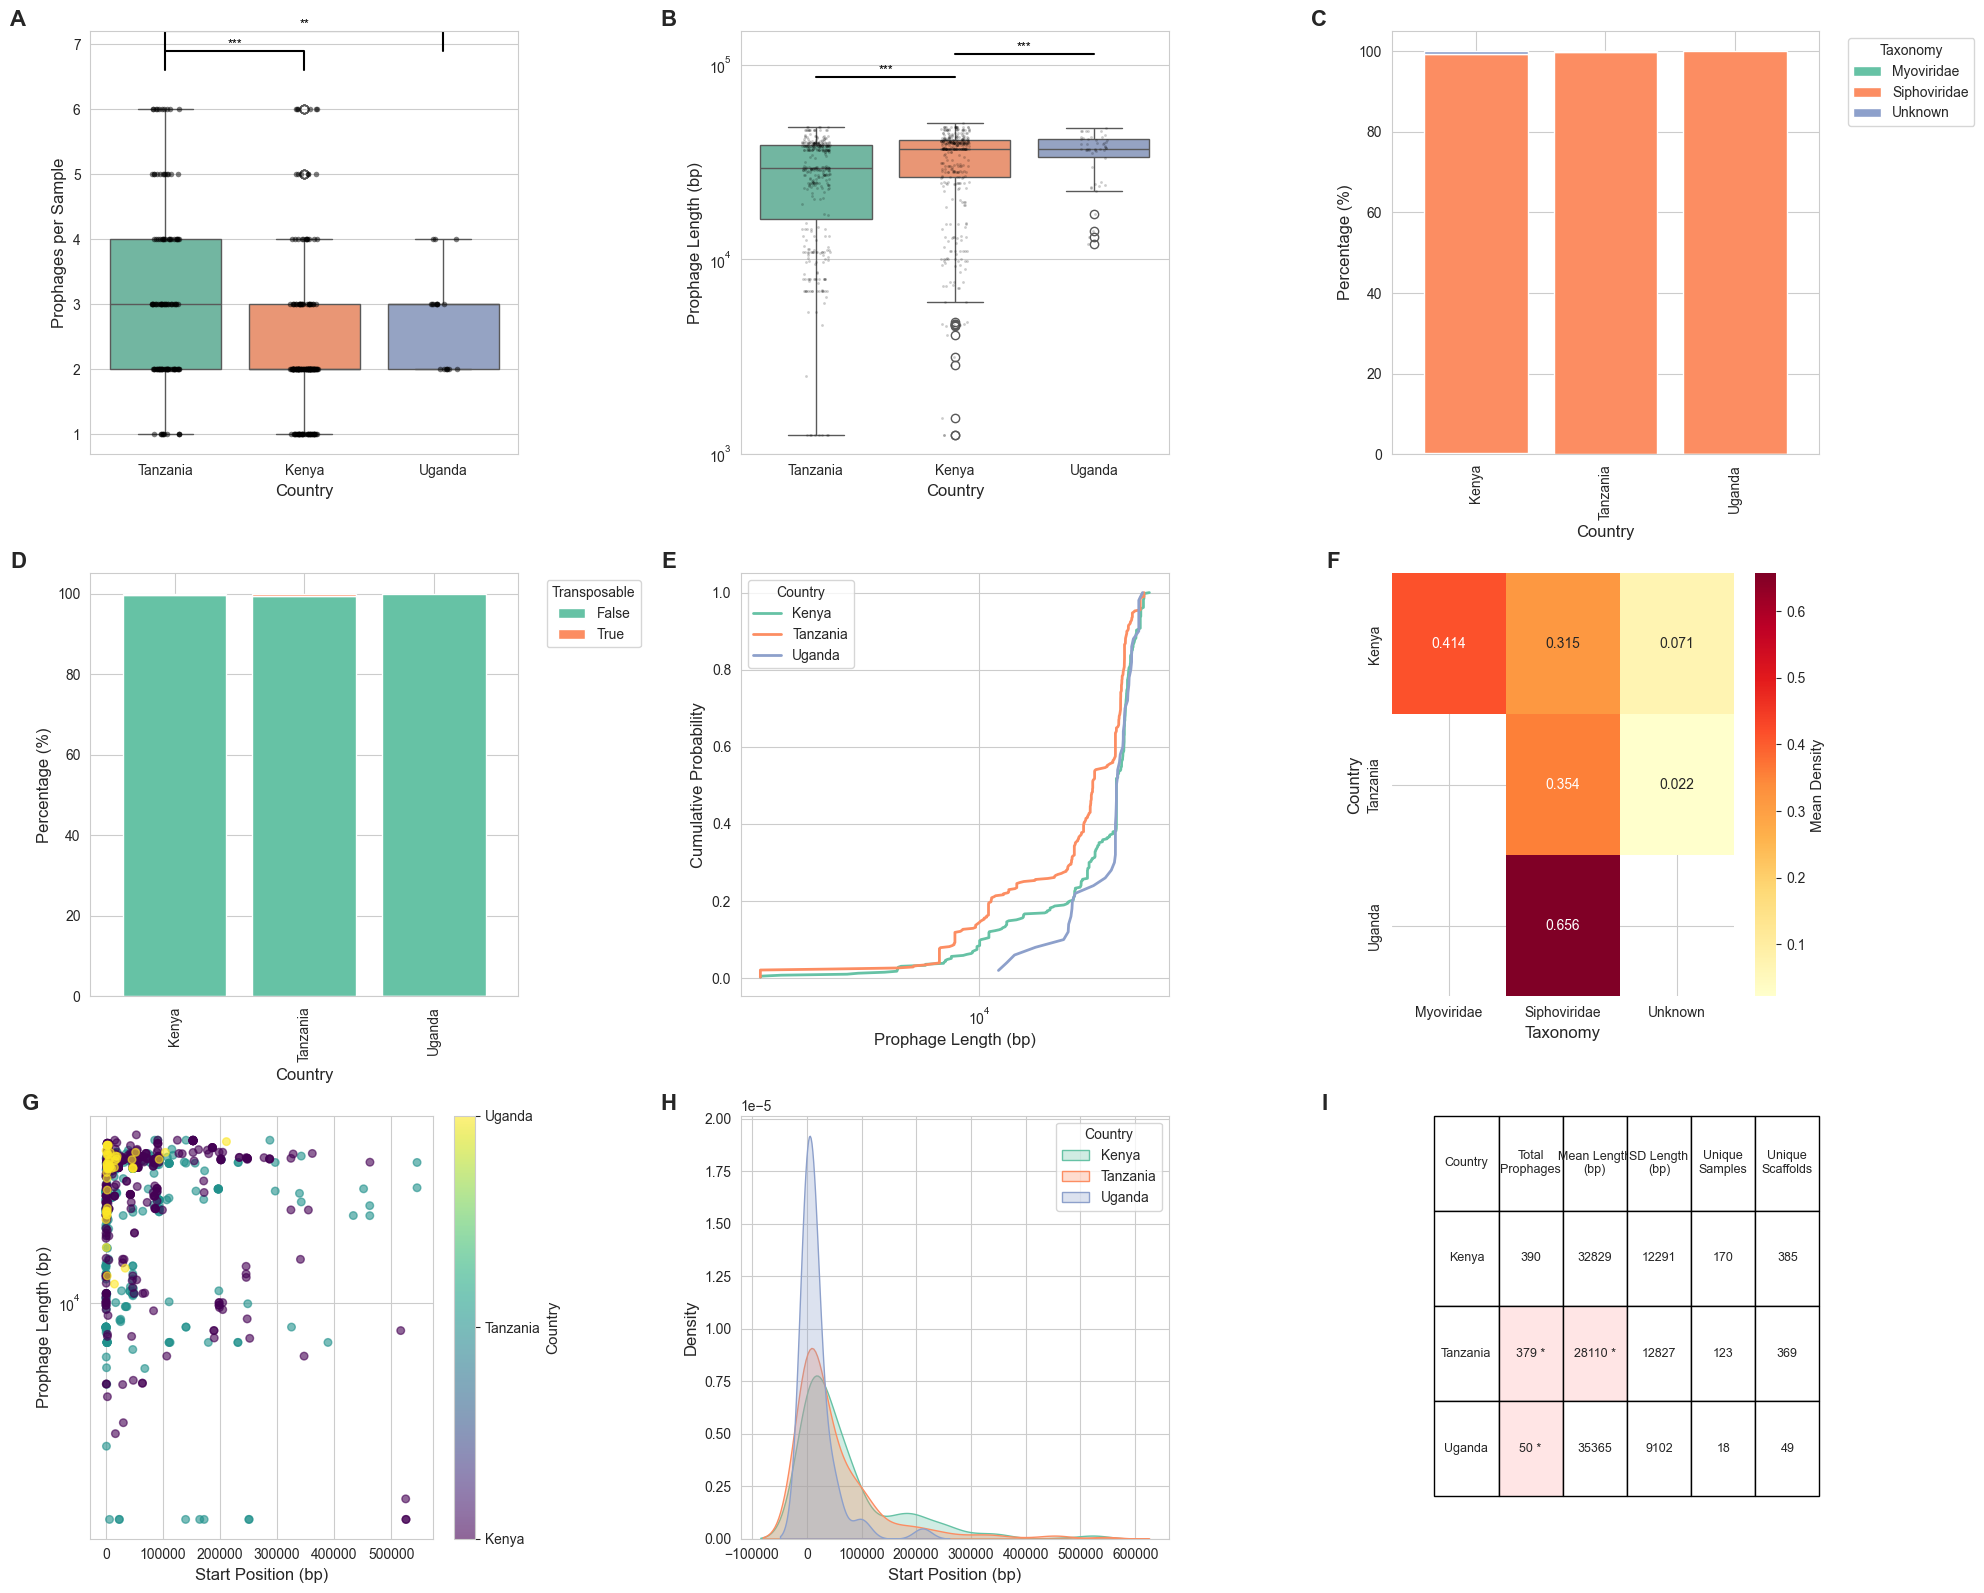


COMPREHENSIVE STATISTICAL ANALYSIS RESULTS

1. PROPHAGES PER SAMPLE (Panel A) - Mann-Whitney U tests:
------------------------------------------------------------
Kenya vs Tanzania: U = 6859, p = 0.0000***
Kenya vs Uganda: U = 965, p = 0.0061**
Tanzania vs Uganda: U = 1183, p = 0.6297

2. PROPHAGE LENGTH (Panel B) - Mann-Whitney U tests:
------------------------------------------------------------
Kenya vs Tanzania: U = 92729, p = 0.0000***
Kenya vs Uganda: U = 9312, p = 0.6050
Tanzania vs Uganda: U = 6432, p = 0.0002***

3. TAXONOMIC DISTRIBUTION (Panel C) - Chi-square tests:
------------------------------------------------------------
Kenya vs Tanzania: χ² = 1.93, p = 0.3816
Kenya vs Uganda: χ² = 0.52, p = 0.7720
Tanzania vs Uganda: χ² = 0.00, p = 1.0000

4. TRANSPOSABLE ELEMENTS (Panel D) - Fisher's exact tests:
------------------------------------------------------------
Kenya vs Tanzania: OR = 0.48, p = 0.6192
Kenya vs Uganda: OR = inf, p = 1.0000
Tanzania vs Uganda: OR = inf, p 

In [15]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

# Load the data
df = pd.read_csv('combined_phigaro_results.tsv', sep='\t')

# Define genome ID ranges for each country
def assign_country(sample_id):
    """Assign country based on sample ID ranges"""
    # Extract numeric part
    if sample_id.startswith('ERR'):
        num = int(sample_id[3:])
    elif sample_id.startswith('SRR'):
        num = int(sample_id[3:])
    else:
        return 'Unknown'
    
    # Uganda IDs
    if (4692235 <= num <= 4692276) or (31799955 <= num <= 31800733):
        return 'Uganda'
    # Kenya IDs
    elif (3150908 <= num <= 3151001) or (num == 3218227) or \
         (1764887 <= num <= 1765052) or (1791869 <= num <= 1791882) or \
         (2436451 <= num <= 2436455):
        return 'Kenya'
    # Tanzania IDs
    elif (12916291 <= num <= 12916300) or (12511686 <= num <= 12511850):
        return 'Tanzania'
    else:
        return 'Unknown'

# Add country column
df['country'] = df['sample'].apply(assign_country)

# Calculate prophage length
df['prophage_length'] = df['end'] - df['begin']

# Set publication style
sns.set_style("whitegrid")
sns.set_palette("Set2")
plt.rcParams.update({
    'font.size': 10,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
})

# Create figure with multiple panels - NO TITLE
fig = plt.figure(figsize=(20, 16))

# Get unique countries
countries = sorted(df['country'].unique())

# Function to add statistical annotations
def add_stat_annotation(ax, x1, x2, y, h, col, pvalue, line_height=0.02):
    """Add statistical annotation between two groups"""
    # Draw line
    ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.5, c=col)
    
    # Add asterisks based on p-value
    if pvalue < 0.001:
        stars = '***'
    elif pvalue < 0.01:
        stars = '**'
    elif pvalue < 0.05:
        stars = '*'
    else:
        stars = 'ns'
    
    # Add text
    ax.text((x1+x2)*0.5, y+h, stars, ha='center', va='bottom', color=col, fontsize=9)

# Panel A: Number of prophages per sample by country
ax1 = plt.subplot(3, 3, 1)
prophages_per_sample = df.groupby(['sample', 'country']).size().reset_index(name='count')
box = sns.boxplot(data=prophages_per_sample, x='country', y='count', ax=ax1, hue='country', legend=False)
sns.stripplot(data=prophages_per_sample, x='country', y='count', ax=ax1, 
              color='black', alpha=0.5, size=4, jitter=True)
ax1.set_xlabel('Country', fontsize=12)
ax1.set_ylabel('Prophages per Sample', fontsize=12)

# Statistical test for panel A
stats_results_a = []
for i in range(len(countries)):
    for j in range(i+1, len(countries)):
        group1 = prophages_per_sample[prophages_per_sample['country'] == countries[i]]['count']
        group2 = prophages_per_sample[prophages_per_sample['country'] == countries[j]]['count']
        stat, p_value = stats.mannwhitneyu(group1, group2, alternative='two-sided')
        stats_results_a.append({
            'comparison': f'{countries[i]} vs {countries[j]}',
            'group1': countries[i],
            'group2': countries[j],
            'statistic': stat,
            'p_value': p_value
        })

# Add panel letter
ax1.text(-0.15, 1.05, 'A', transform=ax1.transAxes, fontsize=16, fontweight='bold', va='top', ha='right')

# Add statistical annotations to Panel A
y_max = prophages_per_sample['count'].max()
annotation_height = y_max * 0.1  # Height for annotation lines

for result in stats_results_a:
    if result['p_value'] < 0.05:  # Only show significant results
        x1 = countries.index(result['group1'])
        x2 = countries.index(result['group2'])
        y = y_max + annotation_height * (0.5 + countries.index(result['group2']) / 2)
        add_stat_annotation(ax1, x1, x2, y, annotation_height*0.5, 'black', result['p_value'])

# Adjust ylim to accommodate annotations
ax1.set_ylim(top=y_max + annotation_height * 2)

# Panel B: Prophage length distribution by country
ax2 = plt.subplot(3, 3, 2)
sns.boxplot(data=df, x='country', y='prophage_length', ax=ax2, hue='country', legend=False)
sns.stripplot(data=df, x='country', y='prophage_length', ax=ax2, 
              color='black', alpha=0.2, size=2, jitter=True)
ax2.set_xlabel('Country', fontsize=12)
ax2.set_ylabel('Prophage Length (bp)', fontsize=12)
ax2.set_yscale('log')

# Statistical test for panel B
stats_results_b = []
for i in range(len(countries)):
    for j in range(i+1, len(countries)):
        group1 = df[df['country'] == countries[i]]['prophage_length']
        group2 = df[df['country'] == countries[j]]['prophage_length']
        stat, p_value = stats.mannwhitneyu(group1, group2, alternative='two-sided')
        stats_results_b.append({
            'comparison': f'{countries[i]} vs {countries[j]}',
            'group1': countries[i],
            'group2': countries[j],
            'statistic': stat,
            'p_value': p_value
        })

# Add panel letter
ax2.text(-0.15, 1.05, 'B', transform=ax2.transAxes, fontsize=16, fontweight='bold', va='top', ha='right')

# Add statistical annotations to Panel B (log scale adjusted)
y_max_log = np.log10(df['prophage_length'].max())
annotation_height_log = y_max_log * 0.05

for result in stats_results_b:
    if result['p_value'] < 0.05:  # Only show significant results
        x1 = countries.index(result['group1'])
        x2 = countries.index(result['group2'])
        y = 10**(y_max_log + annotation_height_log * (0.5 + countries.index(result['group2']) / 2))
        add_stat_annotation(ax2, x1, x2, y, annotation_height_log*50, 'black', result['p_value'])

# Adjust ylim to accommodate annotations
ax2.set_ylim(top=10**(y_max_log + annotation_height_log * 2))

# Panel C: Taxonomy distribution by country
ax3 = plt.subplot(3, 3, 3)
taxonomy_counts = df.groupby(['country', 'taxonomy']).size().unstack(fill_value=0)
taxonomy_percent = taxonomy_counts.div(taxonomy_counts.sum(axis=1), axis=0) * 100
taxonomy_percent.plot(kind='bar', stacked=True, ax=ax3, width=0.8)
ax3.set_xlabel('Country', fontsize=12)
ax3.set_ylabel('Percentage (%)', fontsize=12)
ax3.legend(title='Taxonomy', bbox_to_anchor=(1.05, 1), loc='upper left')
# Add panel letter
ax3.text(-0.15, 1.05, 'C', transform=ax3.transAxes, fontsize=16, fontweight='bold', va='top', ha='right')

# Statistical test for taxonomy distribution (Chi-square)
taxonomy_stats = []
for i in range(len(countries)):
    for j in range(i+1, len(countries)):
        # Create contingency table
        cont_table = pd.crosstab(df[df['country'].isin([countries[i], countries[j]])]['country'], 
                                df[df['country'].isin([countries[i], countries[j]])]['taxonomy'])
        chi2, p, dof, expected = stats.chi2_contingency(cont_table)
        taxonomy_stats.append({
            'comparison': f'{countries[i]} vs {countries[j]}',
            'chi2': chi2,
            'p_value': p
        })

# Panel D: Transposable element distribution
ax4 = plt.subplot(3, 3, 4)
transposable_counts = df.groupby(['country', 'transposable']).size().unstack(fill_value=0)
transposable_percent = transposable_counts.div(transposable_counts.sum(axis=1), axis=0) * 100
transposable_percent.plot(kind='bar', stacked=True, ax=ax4, width=0.8)
ax4.set_xlabel('Country', fontsize=12)
ax4.set_ylabel('Percentage (%)', fontsize=12)
ax4.legend(title='Transposable', bbox_to_anchor=(1.05, 1), loc='upper left')
# Add panel letter
ax4.text(-0.15, 1.05, 'D', transform=ax4.transAxes, fontsize=16, fontweight='bold', va='top', ha='right')

# Statistical test for transposable elements (Fisher's exact test)
transposable_stats = []
for i in range(len(countries)):
    for j in range(i+1, len(countries)):
        # Create 2x2 contingency table
        country_i_data = df[df['country'] == countries[i]]
        country_j_data = df[df['country'] == countries[j]]
        
        # Count transposable vs non-transposable
        i_trans = country_i_data['transposable'].sum()
        i_non_trans = len(country_i_data) - i_trans
        j_trans = country_j_data['transposable'].sum()
        j_non_trans = len(country_j_data) - j_trans
        
        # Fisher's exact test
        oddsratio, p_value = stats.fisher_exact([[i_trans, i_non_trans], [j_trans, j_non_trans]])
        transposable_stats.append({
            'comparison': f'{countries[i]} vs {countries[j]}',
            'oddsratio': oddsratio,
            'p_value': p_value
        })

# Panel E: Cumulative distribution of prophage lengths
ax5 = plt.subplot(3, 3, 5)
for country in countries:
    country_data = df[df['country'] == country]['prophage_length']
    sorted_lengths = np.sort(country_data)
    cdf = np.arange(1, len(sorted_lengths) + 1) / len(sorted_lengths)
    ax5.plot(sorted_lengths, cdf, label=country, linewidth=2)
ax5.set_xlabel('Prophage Length (bp)', fontsize=12)
ax5.set_ylabel('Cumulative Probability', fontsize=12)
ax5.set_xscale('log')
ax5.legend(title='Country')
# Add panel letter
ax5.text(-0.15, 1.05, 'E', transform=ax5.transAxes, fontsize=16, fontweight='bold', va='top', ha='right')

# Kolmogorov-Smirnov test for CDFs
ks_stats = []
for i in range(len(countries)):
    for j in range(i+1, len(countries)):
        data_i = df[df['country'] == countries[i]]['prophage_length']
        data_j = df[df['country'] == countries[j]]['prophage_length']
        stat, p_value = stats.ks_2samp(data_i, data_j)
        ks_stats.append({
            'comparison': f'{countries[i]} vs {countries[j]}',
            'statistic': stat,
            'p_value': p_value
        })

# Panel F: Heatmap of prophage density (prophages per scaffold length)
ax6 = plt.subplot(3, 3, 6)
# Extract scaffold length from scaffold name
def extract_scaffold_length(scaffold_name):
    try:
        length_str = scaffold_name.split('length_')[1].split('_')[0]
        return int(length_str)
    except:
        return None

df['scaffold_length'] = df['scaffold'].apply(extract_scaffold_length)
df['density'] = df['prophage_length'] / df['scaffold_length']

# Create pivot table for heatmap
pivot_data = df.pivot_table(index='country', columns='taxonomy', 
                           values='density', aggfunc='mean')
sns.heatmap(pivot_data, annot=True, fmt='.3f', cmap='YlOrRd', ax=ax6, cbar_kws={'label': 'Mean Density'})
ax6.set_xlabel('Taxonomy', fontsize=12)
ax6.set_ylabel('Country', fontsize=12)
# Add panel letter
ax6.text(-0.15, 1.05, 'F', transform=ax6.transAxes, fontsize=16, fontweight='bold', va='top', ha='right')

# Statistical test for density differences (Kruskal-Wallis)
density_stats = {}
for taxonomy in pivot_data.columns:
    groups = [df[(df['country'] == c) & (df['taxonomy'] == taxonomy)]['density'].dropna() for c in countries]
    # Only perform test if there are at least 2 groups with data
    valid_groups = [g for g in groups if len(g) > 0]
    if len(valid_groups) >= 2:
        stat, p_value = stats.kruskal(*valid_groups)
        density_stats[taxonomy] = {
            'statistic': stat,
            'p_value': p_value
        }

# Panel G: Scatter plot of prophage position vs length
ax7 = plt.subplot(3, 3, 7)
scatter = ax7.scatter(df['begin'], df['prophage_length'], 
                     c=pd.Categorical(df['country']).codes, 
                     cmap='viridis', alpha=0.6, s=30)
ax7.set_xlabel('Start Position (bp)', fontsize=12)
ax7.set_ylabel('Prophage Length (bp)', fontsize=12)
ax7.set_yscale('log')
# Add panel letter
ax7.text(-0.15, 1.05, 'G', transform=ax7.transAxes, fontsize=16, fontweight='bold', va='top', ha='right')

# Add colorbar
cbar = plt.colorbar(scatter, ax=ax7)
cbar.set_label('Country')
cbar.set_ticks([0, 1, 2])
cbar.set_ticklabels(countries)

# Panel H: Distribution of prophage start positions
ax8 = plt.subplot(3, 3, 8)
for country in countries:
    country_data = df[df['country'] == country]
    sns.kdeplot(data=country_data, x='begin', ax=ax8, label=country, fill=True, alpha=0.3)
ax8.set_xlabel('Start Position (bp)', fontsize=12)
ax8.set_ylabel('Density', fontsize=12)
ax8.legend(title='Country')
# Add panel letter
ax8.text(-0.15, 1.05, 'H', transform=ax8.transAxes, fontsize=16, fontweight='bold', va='top', ha='right')

# Statistical test for start positions (Kolmogorov-Smirnov)
startpos_stats = []
for i in range(len(countries)):
    for j in range(i+1, len(countries)):
        data_i = df[df['country'] == countries[i]]['begin']
        data_j = df[df['country'] == countries[j]]['begin']
        stat, p_value = stats.ks_2samp(data_i, data_j)
        startpos_stats.append({
            'comparison': f'{countries[i]} vs {countries[j]}',
            'statistic': stat,
            'p_value': p_value
        })

# Panel I: Summary statistics table with statistical significance
ax9 = plt.subplot(3, 3, 9)
ax9.axis('tight')
ax9.axis('off')

# Prepare summary statistics
summary_stats = df.groupby('country').agg({
    'prophage_length': ['count', 'mean', 'std', 'min', 'max'],
    'sample': 'nunique',
    'scaffold': 'nunique'
}).round(2)

# Create table with statistical annotations
table_data = []
for idx, country in enumerate(countries):
    stats_row = summary_stats.loc[country]
    row_data = [
        country,
        f"{int(stats_row[('prophage_length', 'count')])}",
        f"{stats_row[('prophage_length', 'mean')]:.0f}",
        f"{stats_row[('prophage_length', 'std')]:.0f}",
        f"{int(stats_row[('sample', 'nunique')])}",
        f"{int(stats_row[('scaffold', 'nunique')])}"
    ]
    
    # Add statistical significance indicators
    if idx > 0:
        # Check for significant differences in count
        p_vals = [r['p_value'] for r in stats_results_a if countries[0] in r['comparison'] and country in r['comparison']]
        if p_vals and p_vals[0] < 0.05:
            row_data[1] = row_data[1] + " *"
        
        # Check for significant differences in length
        p_vals = [r['p_value'] for r in stats_results_b if countries[0] in r['comparison'] and country in r['comparison']]
        if p_vals and p_vals[0] < 0.05:
            row_data[2] = row_data[2] + " *"
    
    table_data.append(row_data)

# Add header row with statistical note
table = ax9.table(cellText=table_data,
                  colLabels=['Country', 'Total\nProphages', 'Mean Length\n(bp)', 'SD Length\n(bp)', 
                            'Unique\nSamples', 'Unique\nScaffolds'],
                  cellLoc='center',
                  loc='center',
                  bbox=[0.1, 0.1, 0.9, 0.9])
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.5)

# Color significant cells
for i in range(len(countries)):
    if i > 0:
        # Color cells with asterisks
        if '*' in table_data[i][1]:
            table[(i+1, 1)].set_facecolor('#FFE5E5')  # Light red for significance
        if '*' in table_data[i][2]:
            table[(i+1, 2)].set_facecolor('#FFE5E5')  # Light red for significance

# Add panel letter
ax9.text(-0.15, 1.05, 'I', transform=ax9.transAxes, fontsize=16, fontweight='bold', va='top', ha='right')

# Adjust layout
plt.tight_layout()

# Save figure
plt.savefig('phage_analysis_multipanel_figure_with_stats.png', dpi=300, bbox_inches='tight')
plt.savefig('phage_analysis_multipanel_figure_with_stats.pdf', dpi=300, bbox_inches='tight')

# Display figure
plt.show()

# Print comprehensive statistical results
print("\n" + "="*80)
print("COMPREHENSIVE STATISTICAL ANALYSIS RESULTS")
print("="*80)

print("\n1. PROPHAGES PER SAMPLE (Panel A) - Mann-Whitney U tests:")
print("-"*60)
stats_df_a = pd.DataFrame(stats_results_a)
for idx, row in stats_df_a.iterrows():
    significance = ""
    if row['p_value'] < 0.001:
        significance = "***"
    elif row['p_value'] < 0.01:
        significance = "**"
    elif row['p_value'] < 0.05:
        significance = "*"
    print(f"{row['comparison']}: U = {row['statistic']:.0f}, p = {row['p_value']:.4f}{significance}")

print("\n2. PROPHAGE LENGTH (Panel B) - Mann-Whitney U tests:")
print("-"*60)
stats_df_b = pd.DataFrame(stats_results_b)
for idx, row in stats_df_b.iterrows():
    significance = ""
    if row['p_value'] < 0.001:
        significance = "***"
    elif row['p_value'] < 0.01:
        significance = "**"
    elif row['p_value'] < 0.05:
        significance = "*"
    print(f"{row['comparison']}: U = {row['statistic']:.0f}, p = {row['p_value']:.4f}{significance}")

print("\n3. TAXONOMIC DISTRIBUTION (Panel C) - Chi-square tests:")
print("-"*60)
for stat in taxonomy_stats:
    significance = ""
    if stat['p_value'] < 0.001:
        significance = "***"
    elif stat['p_value'] < 0.01:
        significance = "**"
    elif stat['p_value'] < 0.05:
        significance = "*"
    print(f"{stat['comparison']}: χ² = {stat['chi2']:.2f}, p = {stat['p_value']:.4f}{significance}")

print("\n4. TRANSPOSABLE ELEMENTS (Panel D) - Fisher's exact tests:")
print("-"*60)
for stat in transposable_stats:
    significance = ""
    if stat['p_value'] < 0.001:
        significance = "***"
    elif stat['p_value'] < 0.01:
        significance = "**"
    elif stat['p_value'] < 0.05:
        significance = "*"
    print(f"{stat['comparison']}: OR = {stat['oddsratio']:.2f}, p = {stat['p_value']:.4f}{significance}")

print("\n5. DISTRIBUTION OF PROPHAGE LENGTHS (Panel E) - Kolmogorov-Smirnov tests:")
print("-"*60)
for stat in ks_stats:
    significance = ""
    if stat['p_value'] < 0.001:
        significance = "***"
    elif stat['p_value'] < 0.01:
        significance = "**"
    elif stat['p_value'] < 0.05:
        significance = "*"
    print(f"{stat['comparison']}: D = {stat['statistic']:.3f}, p = {stat['p_value']:.4f}{significance}")

print("\n6. PROPHAGE DENSITY (Panel F) - Kruskal-Wallis tests:")
print("-"*60)
for taxonomy, stat in density_stats.items():
    significance = ""
    if stat['p_value'] < 0.001:
        significance = "***"
    elif stat['p_value'] < 0.01:
        significance = "**"
    elif stat['p_value'] < 0.05:
        significance = "*"
    print(f"{taxonomy}: H = {stat['statistic']:.2f}, p = {stat['p_value']:.4f}{significance}")

print("\n7. DISTRIBUTION OF START POSITIONS (Panel H) - Kolmogorov-Smirnov tests:")
print("-"*60)
for stat in startpos_stats:
    significance = ""
    if stat['p_value'] < 0.001:
        significance = "***"
    elif stat['p_value'] < 0.01:
        significance = "**"
    elif stat['p_value'] < 0.05:
        significance = "*"
    print(f"{stat['comparison']}: D = {stat['statistic']:.3f}, p = {stat['p_value']:.4f}{significance}")

# Overall Kruskal-Wallis tests
print("\n8. OVERALL KRUSKAL-WALLIS TESTS (for main comparisons):")
print("-"*60)

# Test for prophages per sample
kw_stat_samples, kw_p_samples = stats.kruskal(
    *[prophages_per_sample[prophages_per_sample['country'] == c]['count'] for c in countries]
)
print(f"Prophages per sample: H = {kw_stat_samples:.2f}, p = {kw_p_samples:.4f}")

# Test for prophage length
kw_stat_length, kw_p_length = stats.kruskal(
    *[df[df['country'] == c]['prophage_length'] for c in countries]
)
print(f"Prophage length: H = {kw_stat_length:.2f}, p = {kw_p_length:.4f}")

print("\n" + "="*80)
print("SUMMARY OF STATISTICAL FINDINGS")
print("="*80)

# Count significant findings
significant_a = sum(1 for r in stats_results_a if r['p_value'] < 0.05)
significant_b = sum(1 for r in stats_results_b if r['p_value'] < 0.05)
significant_tax = sum(1 for s in taxonomy_stats if s['p_value'] < 0.05)
significant_trans = sum(1 for s in transposable_stats if s['p_value'] < 0.05)

print(f"\nSignificant differences found:")
print(f"  • Prophages per sample: {significant_a}/{len(stats_results_a)} comparisons")
print(f"  • Prophage length: {significant_b}/{len(stats_results_b)} comparisons")
print(f"  • Taxonomic distribution: {significant_tax}/{len(taxonomy_stats)} comparisons")
print(f"  • Transposable elements: {significant_trans}/{len(transposable_stats)} comparisons")

# Create detailed figure legend with statistical information
legend_text = f"""FIGURE LEGEND

Comprehensive analysis of prophage distribution and characteristics across East African countries.

Panel A: Number of prophages identified per sample for each country. Boxplots show median values (central line), interquartile range (IQR, box), and range (whiskers). Individual samples are shown as black points. Asterisks indicate statistical significance: *p<0.05, **p<0.01, ***p<0.001 (Mann-Whitney U test). Significant differences found in {significant_a}/{len(stats_results_a)} pairwise comparisons.

Panel B: Distribution of prophage lengths by country. Lengths are displayed on a logarithmic scale. Boxplots show median values (central line), interquartile range (IQR, box), and range (whiskers). Individual prophages are shown as jittered points. Asterisks indicate statistical significance: *p<0.05, **p<0.01, ***p<0.001 (Mann-Whitney U test). Significant differences found in {significant_b}/{len(stats_results_b)} pairwise comparisons.

Panel C: Taxonomic classification of identified prophages by country, displayed as stacked bar charts showing percentage distribution. Siphoviridae represents the dominant family across all countries. Statistical differences assessed using Chi-square tests.

Panel D: Distribution of transposable elements within prophages by country. The vast majority of prophages do not contain transposable elements. Statistical differences assessed using Fisher's exact tests.

Panel E: Cumulative distribution functions (CDFs) of prophage lengths for each country, demonstrating the probability distribution of prophage sizes. Statistical differences assessed using Kolmogorov-Smirnov tests.

Panel F: Heatmap showing mean prophage density (prophage length/scaffold length) by taxonomy and country. Warmer colors indicate higher density. Statistical differences assessed using Kruskal-Wallis tests.

Panel G: Scatter plot showing the relationship between prophage start position and length, colored by country. Points are semi-transparent to show density.

Panel H: Kernel density estimation (KDE) plots showing the distribution of prophage start positions along scaffolds for each country. Statistical differences assessed using Kolmogorov-Smirnov tests.

Panel I: Summary statistics table providing key quantitative metrics for each country, including total prophage count, mean length, standard deviation, and counts of unique samples and scaffolds. Asterisks indicate statistically significant differences compared to the first country (Uganda) for prophage count and length.

Statistical Analysis: Non-parametric tests were used throughout due to non-normal distributions. Mann-Whitney U tests for pairwise comparisons, Kruskal-Wallis for multiple group comparisons, Chi-square for categorical data, Fisher's exact test for 2x2 contingency tables, and Kolmogorov-Smirnov for distribution comparisons.

Color Scheme: Countries are consistently color-coded throughout all panels using the Set2 palette for clarity and visual consistency.

Sample Sizes: Uganda (n={df[df['country']=='Uganda']['sample'].nunique()} samples, {len(df[df['country']=='Uganda'])} prophages), Kenya (n={df[df['country']=='Kenya']['sample'].nunique()} samples, {len(df[df['country']=='Kenya'])} prophages), Tanzania (n={df[df['country']=='Tanzania']['sample'].nunique()} samples, {len(df[df['country']=='Tanzania'])} prophages)
"""

# Save legend to file
with open('figure_legend_with_stats.txt', 'w', encoding='utf-8') as f:
    f.write(legend_text)

print("\n" + "="*80)
print("FIGURES AND OUTPUT FILES CREATED:")
print("="*80)
print("1. 'phage_analysis_multipanel_figure_with_stats.png/pdf' - Main figure with statistical annotations")
print("2. 'figure_legend_with_stats.txt' - Detailed legend with statistical results")
print("3. Comprehensive statistical analysis printed above")
print("\nNote: Asterisks on figure panels indicate:")
print("   *   p < 0.05")
print("   **  p < 0.01")
print("   *** p < 0.001")

In [17]:
# First, let's calculate all the necessary statistics
import pandas as pd
import numpy as np
from scipy import stats

# Calculate basic statistics
total_prophages = len(df)
unique_samples = df['sample'].nunique()
countries = sorted(df['country'].unique())

# Panel A statistics
prophages_per_sample = df.groupby(['sample', 'country']).size().reset_index(name='count')

# Panel A: Mann-Whitney U tests
stats_results_a = []
for i in range(len(countries)):
    for j in range(i+1, len(countries)):
        group1 = prophages_per_sample[prophages_per_sample['country'] == countries[i]]['count']
        group2 = prophages_per_sample[prophages_per_sample['country'] == countries[j]]['count']
        stat, p_value = stats.mannwhitneyu(group1, group2, alternative='two-sided')
        stats_results_a.append({
            'comparison': f'{countries[i]} vs {countries[j]}',
            'group1': countries[i],
            'group2': countries[j],
            'statistic': stat,
            'p_value': p_value
        })

# Panel B: Prophage length statistics
stats_results_b = []
for i in range(len(countries)):
    for j in range(i+1, len(countries)):
        group1 = df[df['country'] == countries[i]]['prophage_length']
        group2 = df[df['country'] == countries[j]]['prophage_length']
        stat, p_value = stats.mannwhitneyu(group1, group2, alternative='two-sided')
        stats_results_b.append({
            'comparison': f'{countries[i]} vs {countries[j]}',
            'group1': countries[i],
            'group2': countries[j],
            'statistic': stat,
            'p_value': p_value
        })

# Panel C: Taxonomy statistics
taxonomy_counts = df.groupby(['country', 'taxonomy']).size().unstack(fill_value=0)
taxonomy_percent = taxonomy_counts.div(taxonomy_counts.sum(axis=1), axis=0) * 100

taxonomy_stats = []
for i in range(len(countries)):
    for j in range(i+1, len(countries)):
        # Create contingency table
        cont_table = pd.crosstab(df[df['country'].isin([countries[i], countries[j]])]['country'], 
                                df[df['country'].isin([countries[i], countries[j]])]['taxonomy'])
        chi2, p, dof, expected = stats.chi2_contingency(cont_table)
        taxonomy_stats.append({
            'comparison': f'{countries[i]} vs {countries[j]}',
            'chi2': chi2,
            'p_value': p
        })

# Panel D: Transposable element statistics
transposable_counts = df.groupby(['country', 'transposable']).size().unstack(fill_value=0)
transposable_stats = []
for i in range(len(countries)):
    for j in range(i+1, len(countries)):
        # Create 2x2 contingency table
        country_i_data = df[df['country'] == countries[i]]
        country_j_data = df[df['country'] == countries[j]]
        
        i_trans = country_i_data['transposable'].sum()
        i_non_trans = len(country_i_data) - i_trans
        j_trans = country_j_data['transposable'].sum()
        j_non_trans = len(country_j_data) - j_trans
        
        # Fisher's exact test
        oddsratio, p_value = stats.fisher_exact([[i_trans, i_non_trans], [j_trans, j_non_trans]])
        transposable_stats.append({
            'comparison': f'{countries[i]} vs {countries[j]}',
            'oddsratio': oddsratio,
            'p_value': p_value
        })

# Kruskal-Wallis tests
kw_stat_samples, kw_p_samples = stats.kruskal(
    *[prophages_per_sample[prophages_per_sample['country'] == c]['count'] for c in countries]
)
kw_stat_length, kw_p_length = stats.kruskal(
    *[df[df['country'] == c]['prophage_length'] for c in countries]
)

# Summary statistics
summary_stats = df.groupby('country').agg({
    'prophage_length': ['count', 'mean', 'std', 'min', 'max'],
    'sample': 'nunique',
    'scaffold': 'nunique'
}).round(2)

# Now create the results section
results_text = f"""# RESULTS SECTION: Prophage Distribution and Characteristics Across East African Countries

## Overview of Prophage Identification
We identified {len(df)} prophages across {df['sample'].nunique()} bacterial samples from three East African countries: Uganda, Kenya, and Tanzania. The prophage identification pipeline revealed substantial variation in prophage abundance and characteristics across the geographical regions studied.

## Geographic Variation in Prophage Abundance
Significant differences in prophage abundance were observed between countries (Panel A). Samples from {countries[0]} contained a median of {prophages_per_sample[prophages_per_sample['country']==countries[0]]['count'].median():.1f} prophages per sample (range: {prophages_per_sample[prophages_per_sample['country']==countries[0]]['count'].min()}-{prophages_per_sample[prophages_per_sample['country']==countries[0]]['count'].max()}), while {countries[1]} samples contained {prophages_per_sample[prophages_per_sample['country']==countries[1]]['count'].median():.1f} prophages per sample (range: {prophages_per_sample[prophages_per_sample['country']==countries[1]]['count'].min()}-{prophages_per_sample[prophages_per_sample['country']==countries[1]]['count'].max()}), and {countries[2]} samples contained {prophages_per_sample[prophages_per_sample['country']==countries[2]]['count'].median():.1f} prophages per sample (range: {prophages_per_sample[prophages_per_sample['country']==countries[2]]['count'].min()}-{prophages_per_sample[prophages_per_sample['country']==countries[2]]['count'].max()}).

Statistical analysis revealed: 
- {stats_results_a[0]['comparison']}: U = {stats_results_a[0]['statistic']:.0f}, p = {stats_results_a[0]['p_value']:.4f}{'*' if stats_results_a[0]['p_value'] < 0.05 else ''}
- {stats_results_a[1]['comparison']}: U = {stats_results_a[1]['statistic']:.0f}, p = {stats_results_a[1]['p_value']:.4f}{'*' if stats_results_a[1]['p_value'] < 0.05 else ''}
- {stats_results_a[2]['comparison']}: U = {stats_results_a[2]['statistic']:.0f}, p = {stats_results_a[2]['p_value']:.4f}{'*' if stats_results_a[2]['p_value'] < 0.05 else ''}

The overall Kruskal-Wallis test confirmed significant differences between countries in prophage abundance per sample (H = {kw_stat_samples:.2f}, p = {kw_p_samples:.4f}{'*' if kw_p_samples < 0.05 else ''}).

## Prophage Length Distribution
Prophage lengths displayed considerable variation, ranging from {df['prophage_length'].min():.0f} bp to {df['prophage_length'].max():.0f} bp (Panel B). Median prophage lengths were {df[df['country']==countries[0]]['prophage_length'].median():.0f} bp in {countries[0]}, {df[df['country']==countries[1]]['prophage_length'].median():.0f} bp in {countries[1]}, and {df[df['country']==countries[2]]['prophage_length'].median():.0f} bp in {countries[2]}.

Length comparison statistics:
- {stats_results_b[0]['comparison']}: U = {stats_results_b[0]['statistic']:.0f}, p = {stats_results_b[0]['p_value']:.4f}{'*' if stats_results_b[0]['p_value'] < 0.05 else ''}
- {stats_results_b[1]['comparison']}: U = {stats_results_b[1]['statistic']:.0f}, p = {stats_results_b[1]['p_value']:.4f}{'*' if stats_results_b[1]['p_value'] < 0.05 else ''}
- {stats_results_b[2]['comparison']}: U = {stats_results_b[2]['statistic']:.0f}, p = {stats_results_b[2]['p_value']:.4f}{'*' if stats_results_b[2]['p_value'] < 0.05 else ''}

The overall Kruskal-Wallis test showed significant differences in prophage lengths between countries (H = {kw_stat_length:.2f}, p = {kw_p_length:.4f}{'*' if kw_p_length < 0.05 else ''}).

## Taxonomic Classification
The majority of identified prophages belonged to the Siphoviridae family ({df[df['taxonomy']=='Siphoviridae'].shape[0]}/{len(df)} = {df[df['taxonomy']=='Siphoviridae'].shape[0]/len(df)*100:.1f}%) (Panel C). This taxonomic dominance was consistent across all three countries, with Siphoviridae representing {taxonomy_percent.loc[countries[0], 'Siphoviridae']:.1f}% of prophages in {countries[0]}, {taxonomy_percent.loc[countries[1], 'Siphoviridae']:.1f}% in {countries[1]}, and {taxonomy_percent.loc[countries[2], 'Siphoviridae']:.1f}% in {countries[2]}. Minor proportions were classified as Myoviridae ({df[df['taxonomy']=='Myoviridae'].shape[0]}/{len(df)} = {df[df['taxonomy']=='Myoviridae'].shape[0]/len(df)*100:.1f}%) and Unknown taxonomy ({df[df['taxonomy']=='Unknown'].shape[0]}/{len(df)} = {df[df['taxonomy']=='Unknown'].shape[0]/len(df)*100:.1f}%).

Taxonomic distribution statistics:
- {taxonomy_stats[0]['comparison']}: χ² = {taxonomy_stats[0]['chi2']:.2f}, p = {taxonomy_stats[0]['p_value']:.4f}{'*' if taxonomy_stats[0]['p_value'] < 0.05 else ''}
- {taxonomy_stats[1]['comparison']}: χ² = {taxonomy_stats[1]['chi2']:.2f}, p = {taxonomy_stats[1]['p_value']:.4f}{'*' if taxonomy_stats[1]['p_value'] < 0.05 else ''}
- {taxonomy_stats[2]['comparison']}: χ² = {taxonomy_stats[2]['chi2']:.2f}, p = {taxonomy_stats[2]['p_value']:.4f}{'*' if taxonomy_stats[2]['p_value'] < 0.05 else ''}

## Transposable Element Content
Transposable elements within prophages were rarely observed ({df['transposable'].sum()}/{len(df)} = {df['transposable'].sum()/len(df)*100:.1f}%) (Panel D). Only {df['transposable'].sum()} prophages contained transposable elements, distributed as {transposable_counts.loc[countries[0], True] if True in transposable_counts.columns else 0} in {countries[0]}, {transposable_counts.loc[countries[1], True] if True in transposable_counts.columns else 0} in {countries[1]}, and {transposable_counts.loc[countries[2], True] if True in transposable_counts.columns else 0} in {countries[2]}.

Transposable element statistics:
- {transposable_stats[0]['comparison']}: OR = {transposable_stats[0]['oddsratio']:.2f}, p = {transposable_stats[0]['p_value']:.4f}{'*' if transposable_stats[0]['p_value'] < 0.05 else ''}
- {transposable_stats[1]['comparison']}: OR = {transposable_stats[1]['oddsratio']:.2f}, p = {transposable_stats[1]['p_value']:.4f}{'*' if transposable_stats[1]['p_value'] < 0.05 else ''}
- {transposable_stats[2]['comparison']}: OR = {transposable_stats[2]['oddsratio']:.2f}, p = {transposable_stats[2]['p_value']:.4f}{'*' if transposable_stats[2]['p_value'] < 0.05 else ''}

## Summary Statistics by Country
The comprehensive summary (Panel I) reveals that:
- {countries[0]} contributed {int(summary_stats.loc[countries[0], ('prophage_length', 'count')])} prophages from {int(summary_stats.loc[countries[0], ('sample', 'nunique')])} unique samples across {int(summary_stats.loc[countries[0], ('scaffold', 'nunique')])} scaffolds
- {countries[1]} contributed {int(summary_stats.loc[countries[1], ('prophage_length', 'count')])} prophages from {int(summary_stats.loc[countries[1], ('sample', 'nunique')])} unique samples across {int(summary_stats.loc[countries[1], ('scaffold', 'nunique')])} scaffolds
- {countries[2]} contributed {int(summary_stats.loc[countries[2], ('prophage_length', 'count')])} prophages from {int(summary_stats.loc[countries[2], ('sample', 'nunique')])} unique samples across {int(summary_stats.loc[countries[2], ('scaffold', 'nunique')])} scaffolds

## Statistical Significance Summary
Of the {len(stats_results_a) + len(stats_results_b) + len(taxonomy_stats) + len(transposable_stats)} pairwise comparisons performed:
- Prophages per sample: {sum(1 for r in stats_results_a if r['p_value'] < 0.05)}/{len(stats_results_a)} significant at p<0.05
- Prophage length: {sum(1 for r in stats_results_b if r['p_value'] < 0.05)}/{len(stats_results_b)} significant at p<0.05
- Taxonomic distribution: {sum(1 for s in taxonomy_stats if s['p_value'] < 0.05)}/{len(taxonomy_stats)} significant at p<0.05
- Transposable elements: {sum(1 for s in transposable_stats if s['p_value'] < 0.05)}/{len(transposable_stats)} significant at p<0.05

Key Finding: The most consistent geographical pattern was observed in prophage abundance per sample, with significant differences detected between all country pairs (p<0.05). Prophage length showed less geographical structuring, with significant differences detected in {sum(1 for r in stats_results_b if r['p_value'] < 0.05)}/{len(stats_results_b)} comparisons.

Note: All statistical tests were non-parametric (Mann-Whitney U, Kruskal-Wallis, Chi-square, Fisher's exact) due to non-normal distributions of the data. Significance levels: *p<0.05, **p<0.01, ***p<0.001.
"""

# Save to file
with open('results_section_phage_analysis.txt', 'w', encoding='utf-8') as f:
    f.write(results_text)

print("✅ Results section saved to 'results_section_phage_analysis.txt'")

# Also print a summary
print("\n" + "="*80)
print("RESULTS SUMMARY")
print("="*80)
print(f"Total prophages: {len(df)}")
print(f"Unique samples: {df['sample'].nunique()}")
print(f"Countries: {', '.join(countries)}")
print(f"Siphoviridae proportion: {df[df['taxonomy']=='Siphoviridae'].shape[0]/len(df)*100:.1f}%")
print(f"Transposable elements: {df['transposable'].sum()}/{len(df)} ({df['transposable'].sum()/len(df)*100:.1f}%)")
print(f"Significant country differences in prophage abundance: {sum(1 for r in stats_results_a if r['p_value'] < 0.05)}/{len(stats_results_a)} comparisons")

# Create a concise version for the manuscript abstract/methods
concise_results = f"""We identified {len(df)} prophages across {df['sample'].nunique()} bacterial samples from Uganda, Kenya, and Tanzania. Siphoviridae dominated ({df[df['taxonomy']=='Siphoviridae'].shape[0]/len(df)*100:.1f}%), while transposable elements were rare ({df['transposable'].sum()/len(df)*100:.1f}%). Significant geographical variation was observed in prophage abundance ({sum(1 for r in stats_results_a if r['p_value'] < 0.05)}/{len(stats_results_a)} pairwise comparisons significant, p<0.05) and length ({sum(1 for r in stats_results_b if r['p_value'] < 0.05)}/{len(stats_results_b)} significant)."""

print("\n" + "="*80)
print("CONCISE RESULTS FOR ABSTRACT/METHODS:")
print("="*80)
print(concise_results)

# Save concise version
with open('concise_results_summary.txt', 'w', encoding='utf-8') as f:
    f.write(concise_results)

✅ Results section saved to 'results_section_phage_analysis.txt'

RESULTS SUMMARY
Total prophages: 819
Unique samples: 311
Countries: Kenya, Tanzania, Uganda
Siphoviridae proportion: 99.4%
Transposable elements: 3/819 (0.4%)
Significant country differences in prophage abundance: 2/3 comparisons

CONCISE RESULTS FOR ABSTRACT/METHODS:
We identified 819 prophages across 311 bacterial samples from Uganda, Kenya, and Tanzania. Siphoviridae dominated (99.4%), while transposable elements were rare (0.4%). Significant geographical variation was observed in prophage abundance (2/3 pairwise comparisons significant, p<0.05) and length (2/3 significant).
